In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

MAT keys: ['CIR']
CIR shape: (4095, 281) dtype: complex128
Interpreted as (delay_chips, no. of CIRs) = (4095, 281)


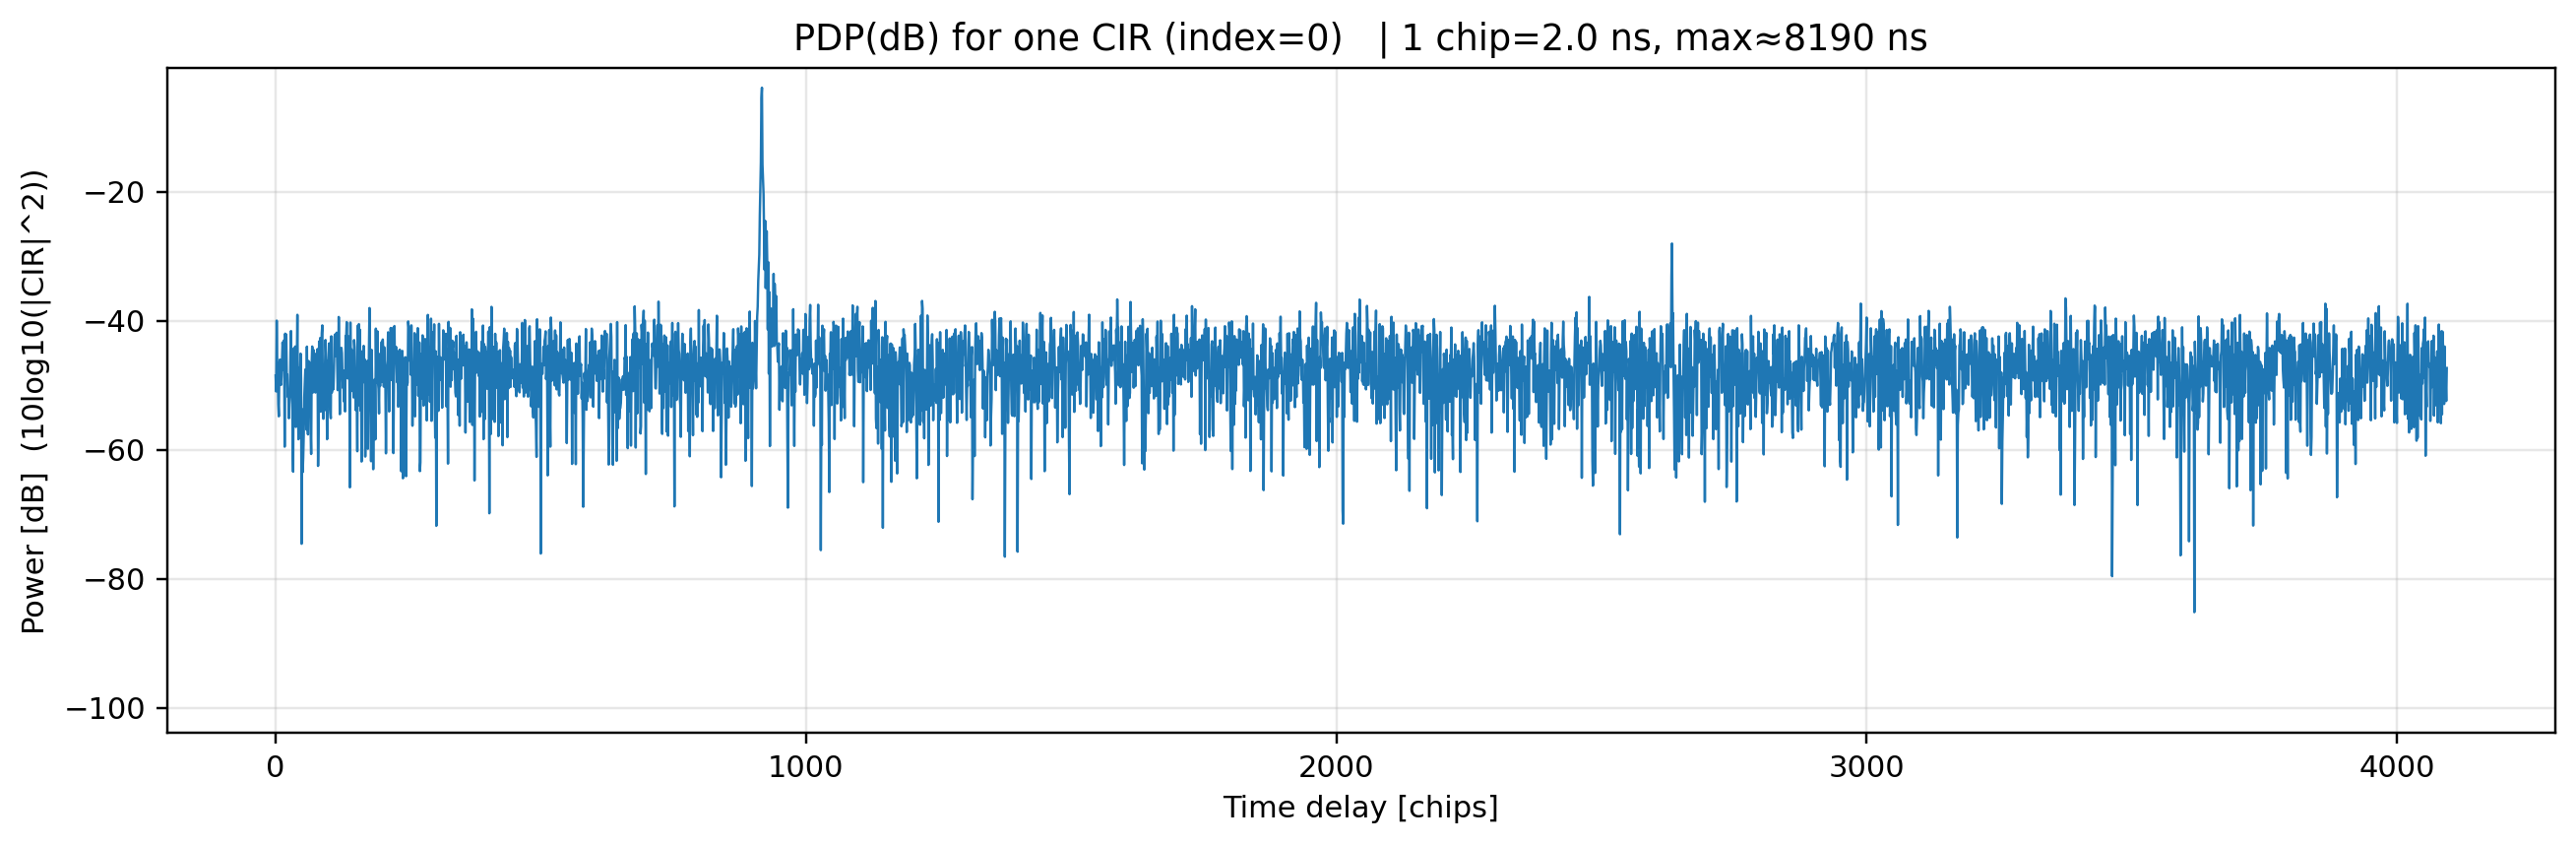

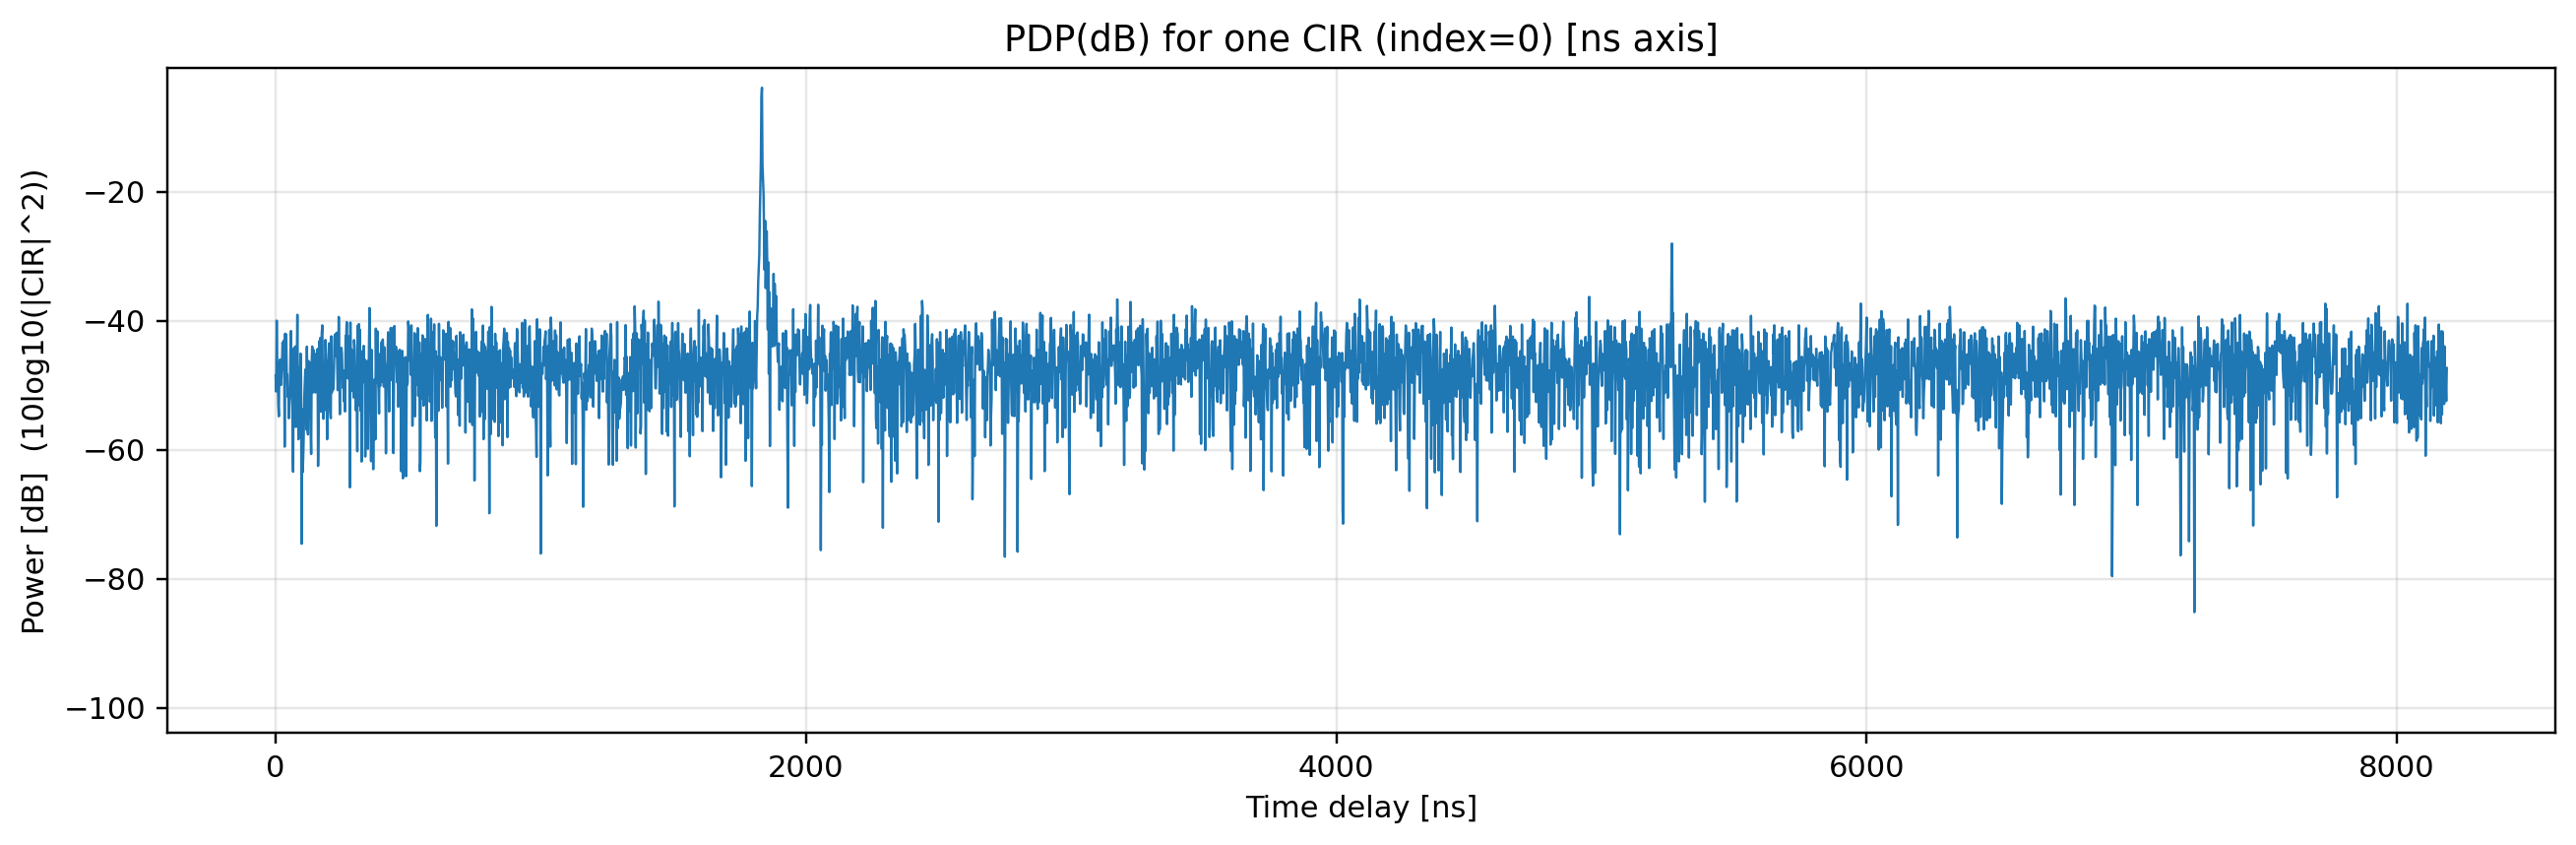

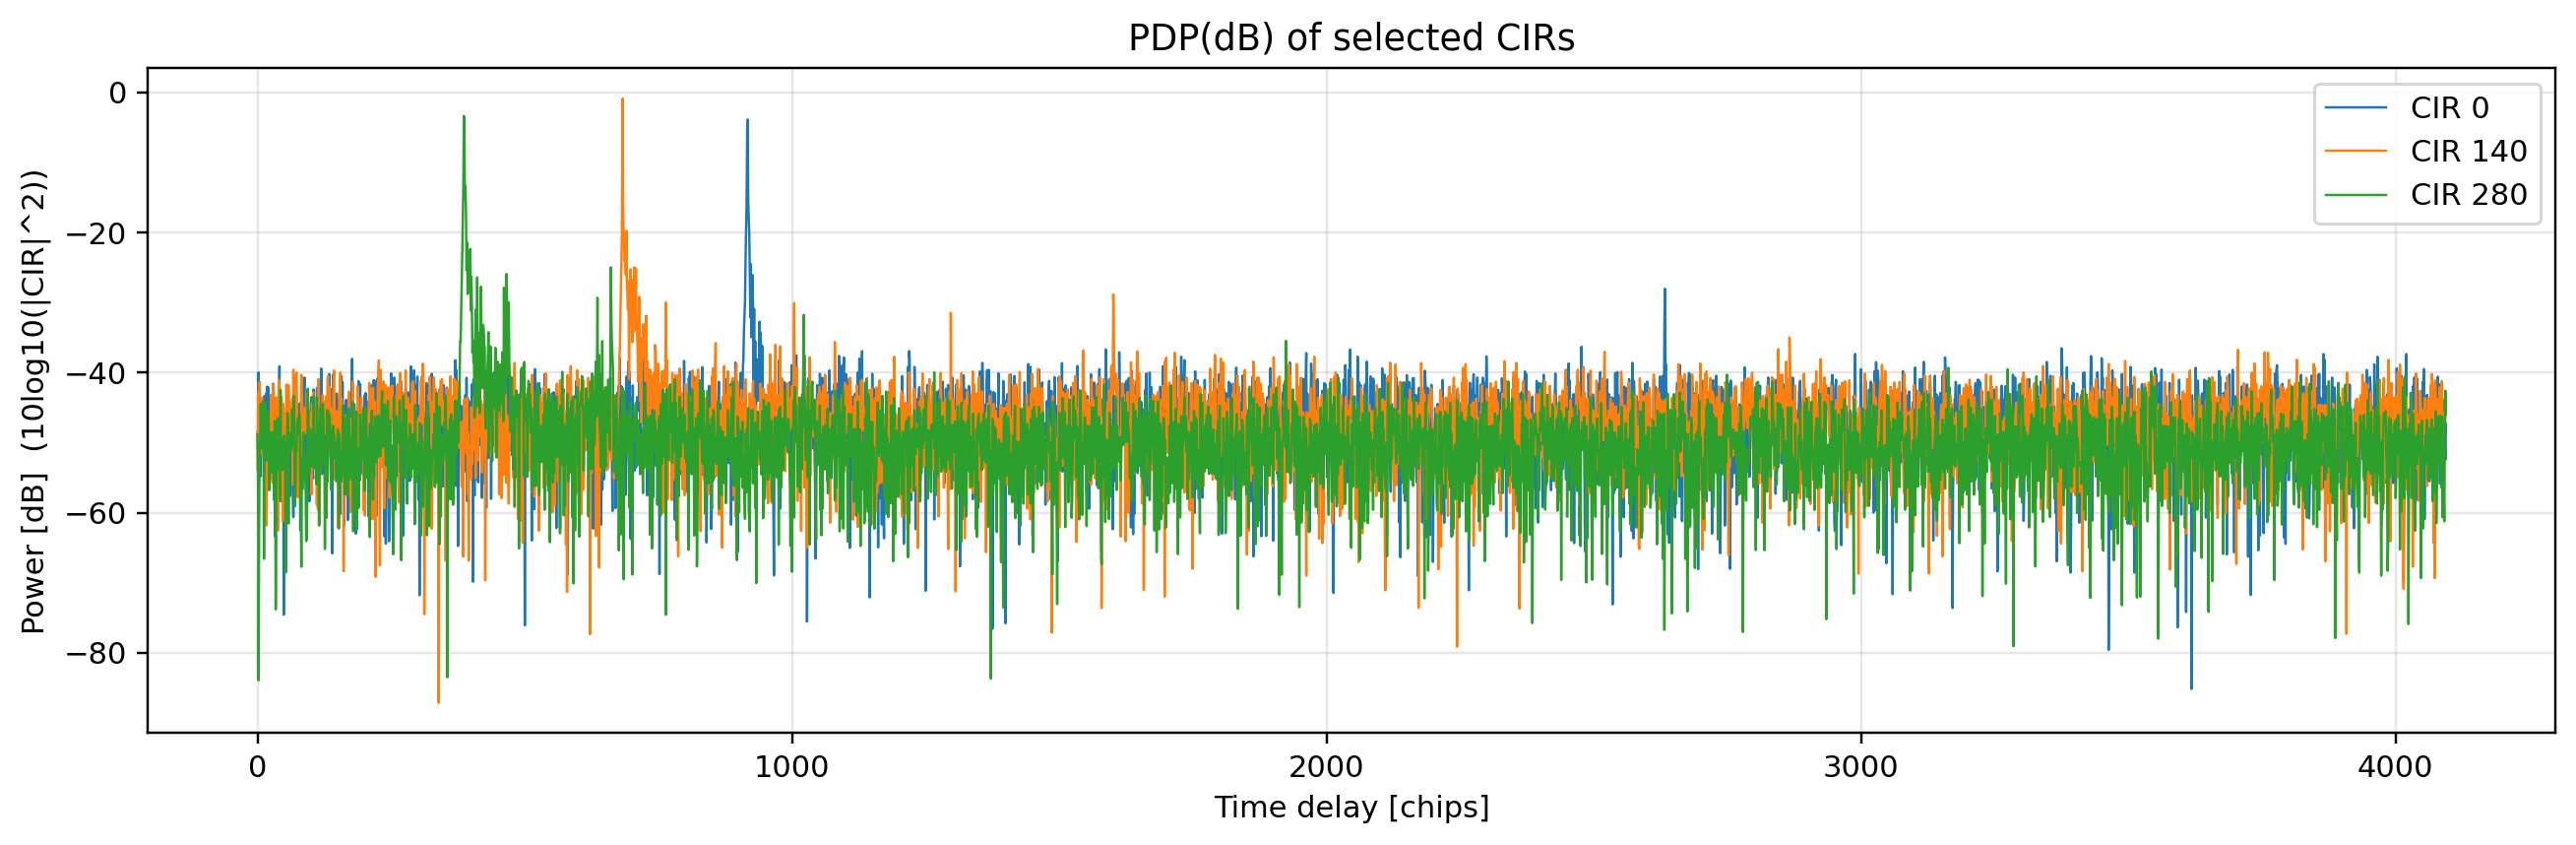

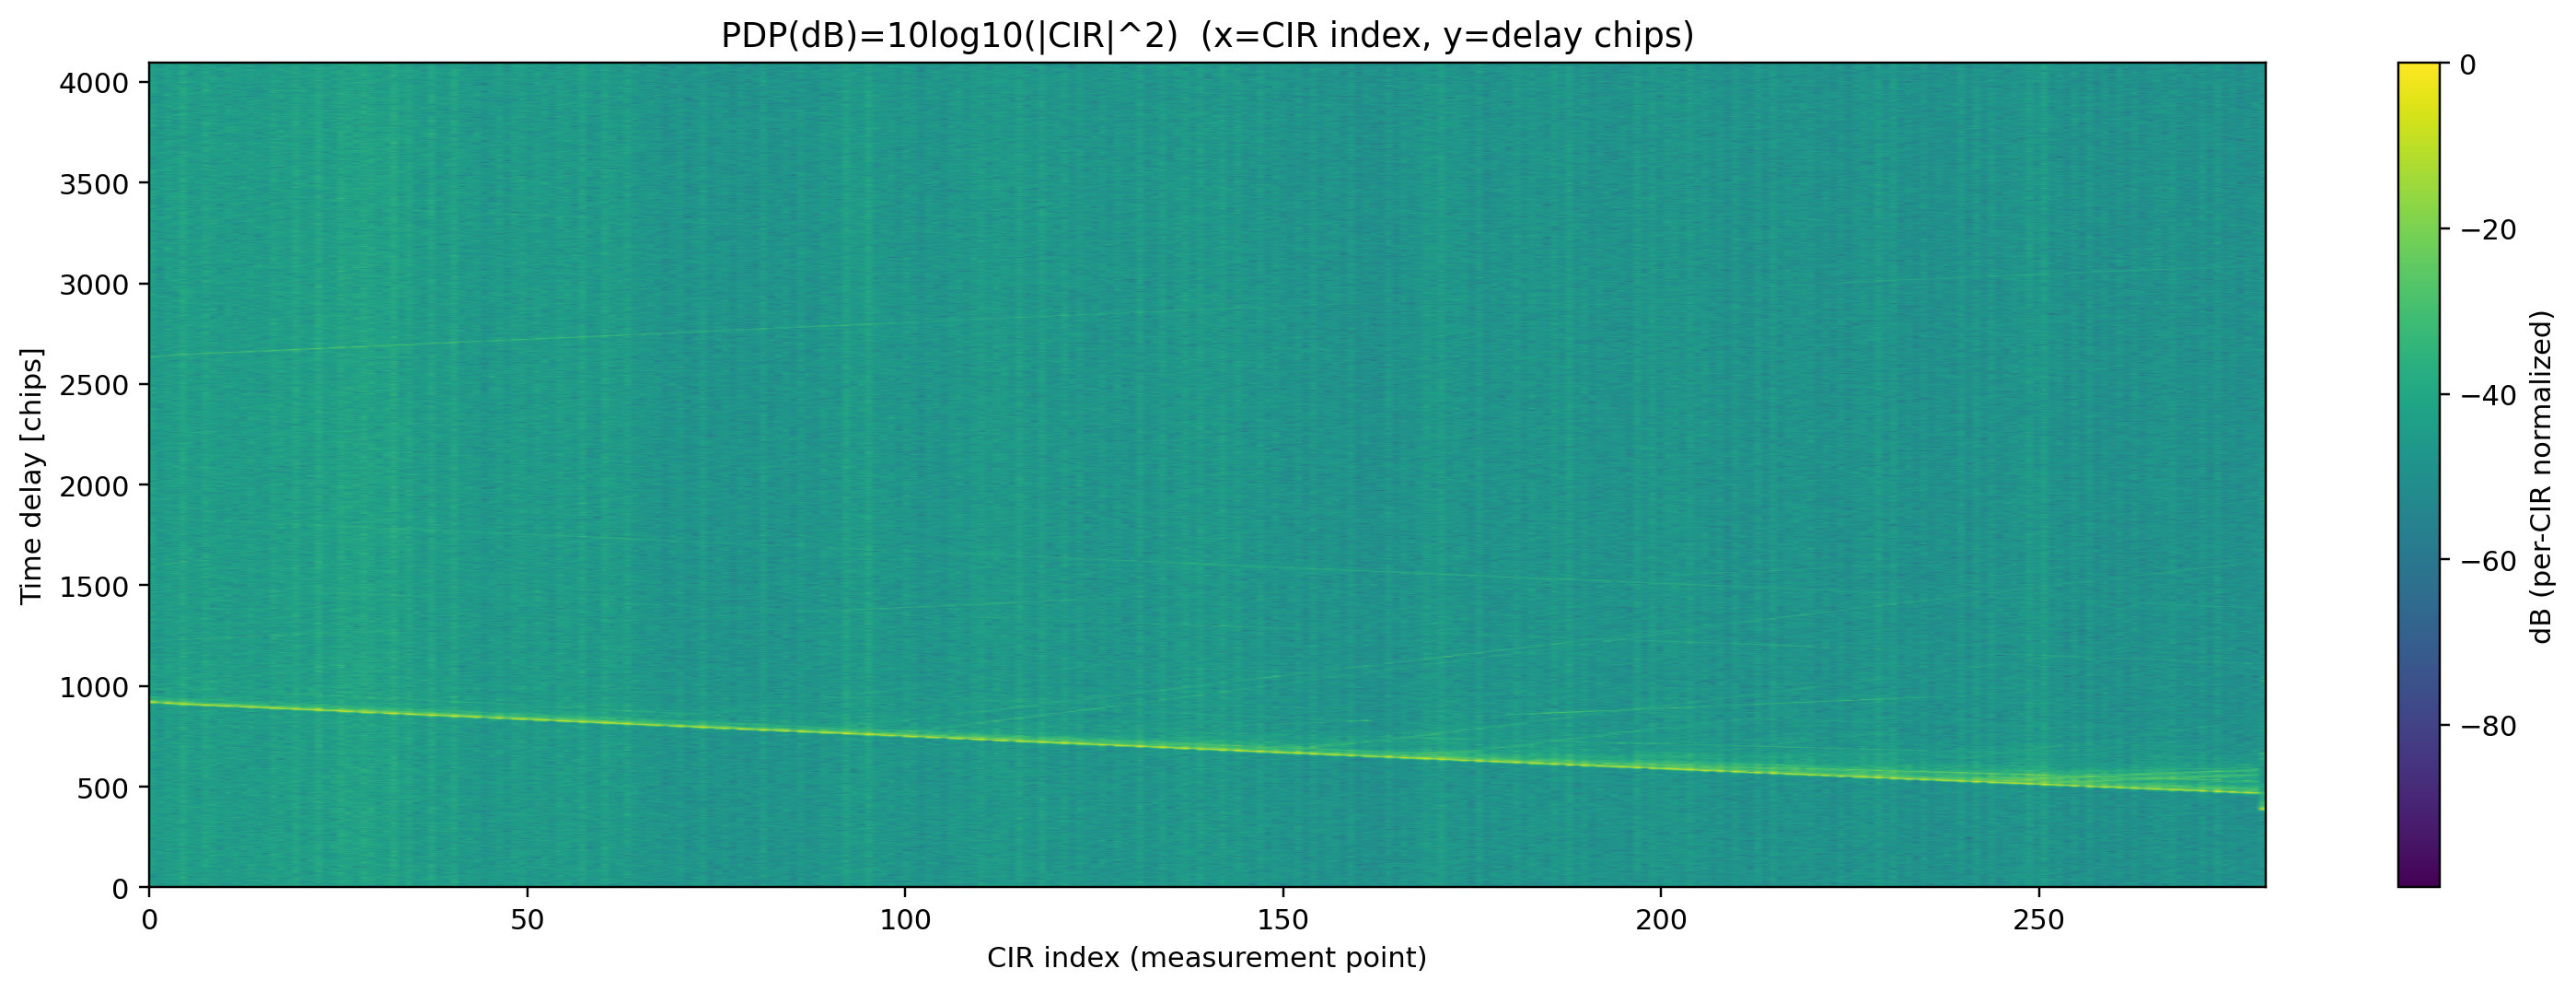

Done.
Max delay ≈ 8190 ns  (= 4095 chips × 2.0 ns/chip)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# =========================
# 0) Config
# =========================
mat_path = "/home/mh/kmh/data/28GHz_chsounder/1/CIR.mat"
cir_key = "CIR"

chip_ns = 2.0          # 1 chip = 2 ns (그림 기준)
dyn_range_db = 100     # y축 표시 범위 (필요시 조절)
n_show = 0             # "PDP(dB)=10log10(|CIR|^2)"를 어느 CIR(n)로 볼지 (0~280)

# =========================
# 1) Load MAT
# =========================
mat = loadmat(mat_path)
keys = [k for k in mat.keys() if not k.startswith("__")]
print("MAT keys:", keys)

assert cir_key in mat, f"'{cir_key}' not found. keys={keys}"
cir_raw = mat[cir_key]

# =========================
# 2) Convert to complex & squeeze
# =========================
def to_complex(x: np.ndarray) -> np.ndarray:
    if np.iscomplexobj(x):
        return x
    if x.ndim >= 1 and x.shape[-1] == 2:
        return x[..., 0] + 1j * x[..., 1]
    raise ValueError(f"Cannot convert to complex: shape={x.shape}, dtype={x.dtype}")

cir = to_complex(cir_raw).squeeze()

if cir.ndim != 2:
    raise ValueError(f"Expected 2D after squeeze, got {cir.shape}. 축 정리가 필요할 수 있음.")

# =========================
# 3) Interpret axes: (delay_chips, no. of CIRs)
#    너가 준 정보대로: (4095, 281) = (delay, measurement points)
# =========================
if cir.shape[0] == 4095:
    cir_dn = cir  # (D,N)
elif cir.shape[1] == 4095:
    cir_dn = np.swapaxes(cir, 0, 1)
else:
    raise ValueError(f"4095 길이 축을 못 찾았어. cir.shape={cir.shape}")

D, N = cir_dn.shape
print("CIR shape:", cir_dn.shape, "dtype:", cir_dn.dtype)
print(f"Interpreted as (delay_chips, no. of CIRs) = ({D}, {N})")

# =========================
# 4) Delay axis (chips -> ns)
# =========================
delay_chips = np.arange(D)                 # 0..4094
delay_ns = delay_chips * chip_ns           # ns
max_delay_ns = D * chip_ns

# =========================
# 5) PDP(dB) = 10*log10(|CIR|^2)
#    - 이 식은 "평균 PDP"가 아니라,
#      각 CIR(측정 포인트)별 delay power profile을 dB로 바꾼 값임.
#    - 즉 결과는 (4095, 281) 전체가 "PDP(dB)" 행렬이 됨.
# =========================
pdp_db_all = 10.0 * np.log10(np.maximum(np.abs(cir_dn)**2, 1e-30))  # (D,N)

# (선택) 보기 편하게 각 CIR별 peak=0 dB 정규화
pdp_db_all_norm = pdp_db_all - pdp_db_all.max(axis=0, keepdims=True)

# =========================
# 6) Plot A: 한 개 CIR(n_show)의 PDP(dB) (그림처럼 x=delay[chips])
# =========================
n_show = int(np.clip(n_show, 0, N-1))
pdp_db_one = pdp_db_all[:, n_show]

plt.figure(figsize=(12,4), dpi=220)
plt.plot(delay_chips, pdp_db_one, linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.xlabel("Time delay [chips]")
plt.ylabel("Power [dB]  (10log10(|CIR|^2))")
plt.title(f"PDP(dB) for one CIR (index={n_show})   | 1 chip={chip_ns} ns, max≈{max_delay_ns:.0f} ns")
plt.ylim(pdp_db_one.max() - dyn_range_db, pdp_db_one.max() + 3)
plt.tight_layout()
plt.show()

# (옵션) x축 ns 버전
plt.figure(figsize=(12,4), dpi=220)
plt.plot(delay_ns, pdp_db_one, linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.xlabel("Time delay [ns]")
plt.ylabel("Power [dB]  (10log10(|CIR|^2))")
plt.title(f"PDP(dB) for one CIR (index={n_show}) [ns axis]")
plt.ylim(pdp_db_one.max() - dyn_range_db, pdp_db_one.max() + 3)
plt.tight_layout()
plt.show()

# =========================
# 7) Plot B: 281개 CIR을 한 그림에 겹치면 너무 지저분하니
#            "대표로 몇 개만" 겹쳐보기 (예: 0, N//2, N-1)
# =========================
sel = [0, N//2, N-1]
plt.figure(figsize=(12,4), dpi=220)
for n in sel:
    plt.plot(delay_chips, pdp_db_all[:, n], linewidth=0.8, label=f"CIR {n}")
plt.grid(True, alpha=0.3)
plt.xlabel("Time delay [chips]")
plt.ylabel("Power [dB]  (10log10(|CIR|^2))")
plt.title("PDP(dB) of selected CIRs")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8) Plot C: Heatmap (x = CIR index(281), y = delay chips(4095))
#            - 그대로(dB) 또는 per-CIR normalized(dB) 중 선택
# =========================
use_norm = True  # True면 각 CIR별 peak=0 dB로 정규화해서 패턴 보기 쉬움
Z = pdp_db_all_norm if use_norm else pdp_db_all

plt.figure(figsize=(14,5), dpi=220)
plt.imshow(
    Z, aspect="auto", origin="lower",
    extent=[0, N-1, delay_chips.min(), delay_chips.max()]
)
plt.colorbar(label="dB (per-CIR normalized)" if use_norm else "dB")
plt.xlabel("CIR index (measurement point)")
plt.ylabel("Time delay [chips]")
plt.title("PDP(dB)=10log10(|CIR|^2)  (x=CIR index, y=delay chips)")
plt.tight_layout()
plt.show()

print("Done.")
print(f"Max delay ≈ {max_delay_ns:.0f} ns  (= {D} chips × {chip_ns} ns/chip)")


CIR one-shot shape: (4095,) dtype: complex128
Example h[0]: (-0.0035936446020560942-0.0011380371705988258j)


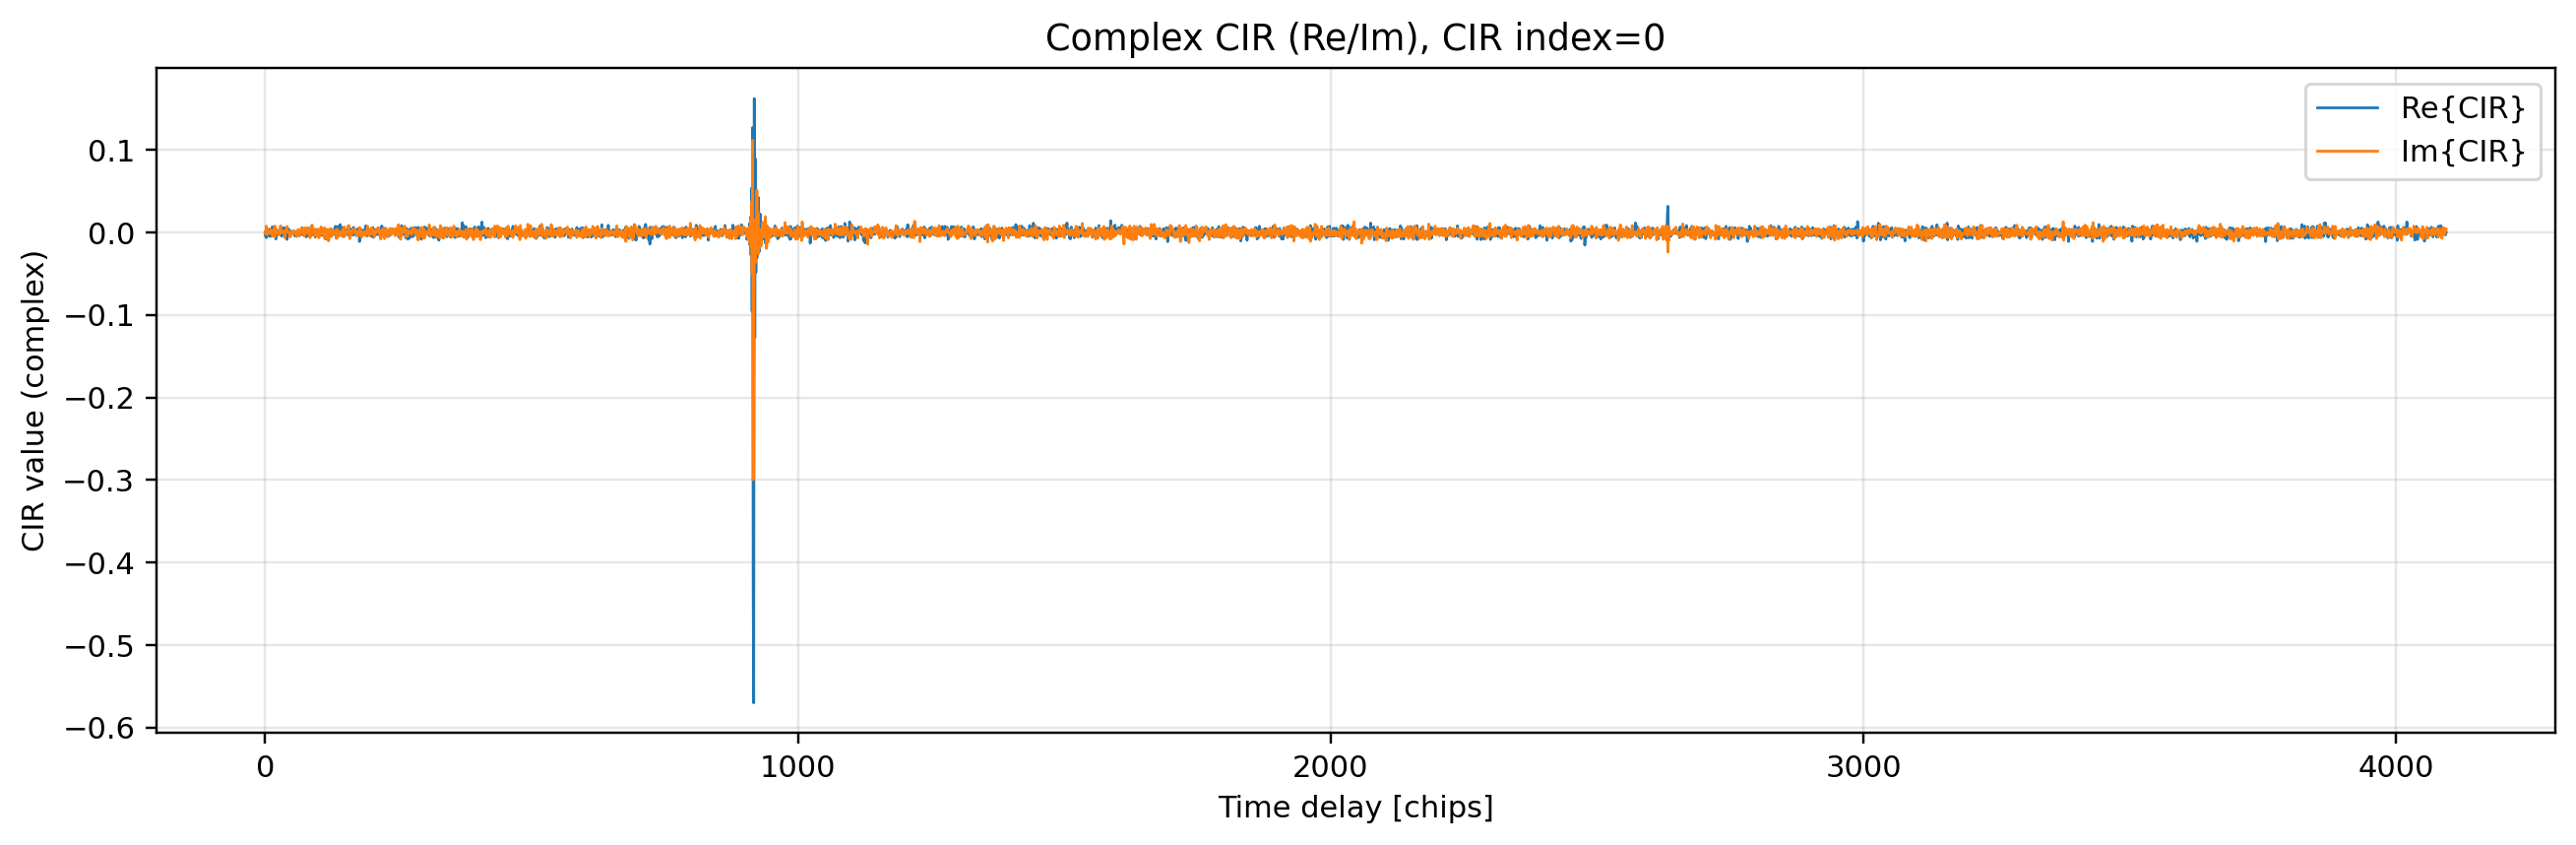

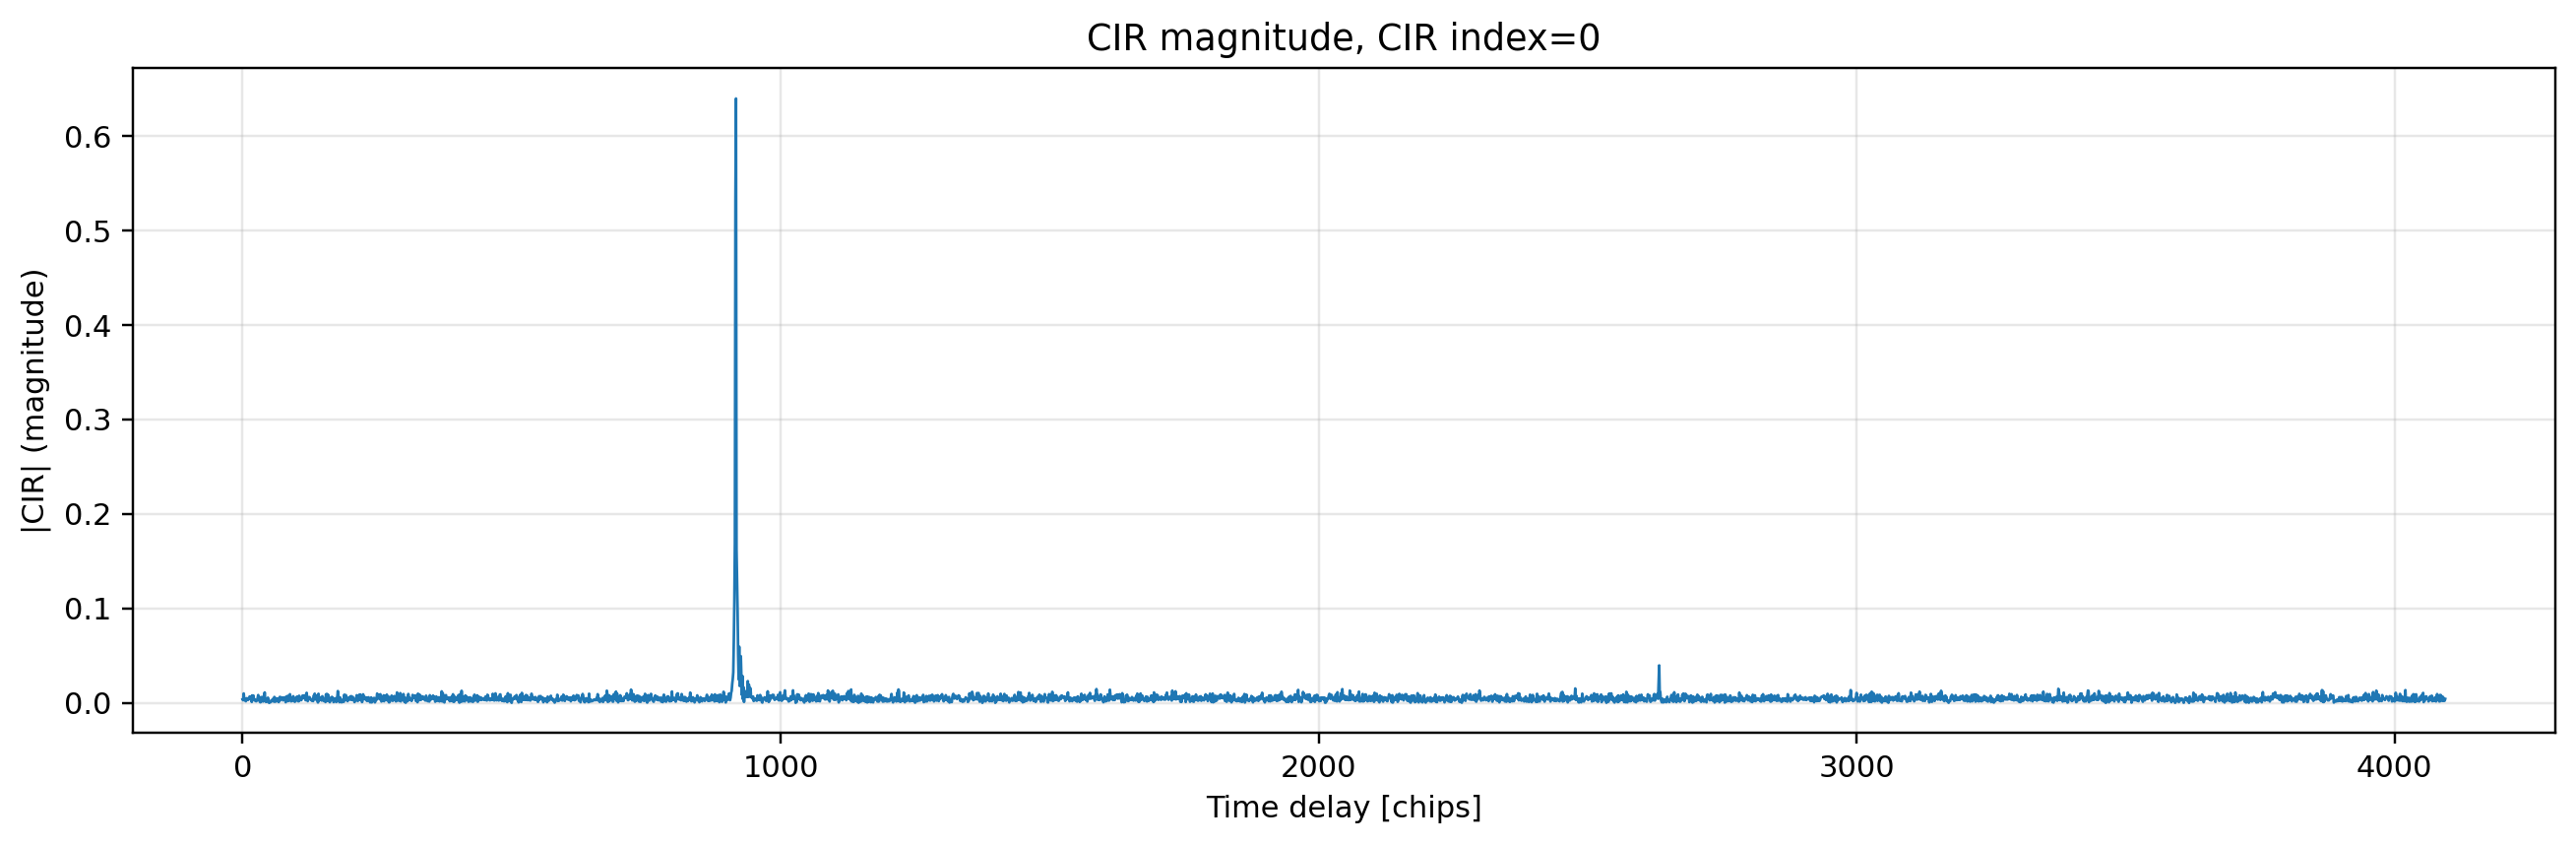

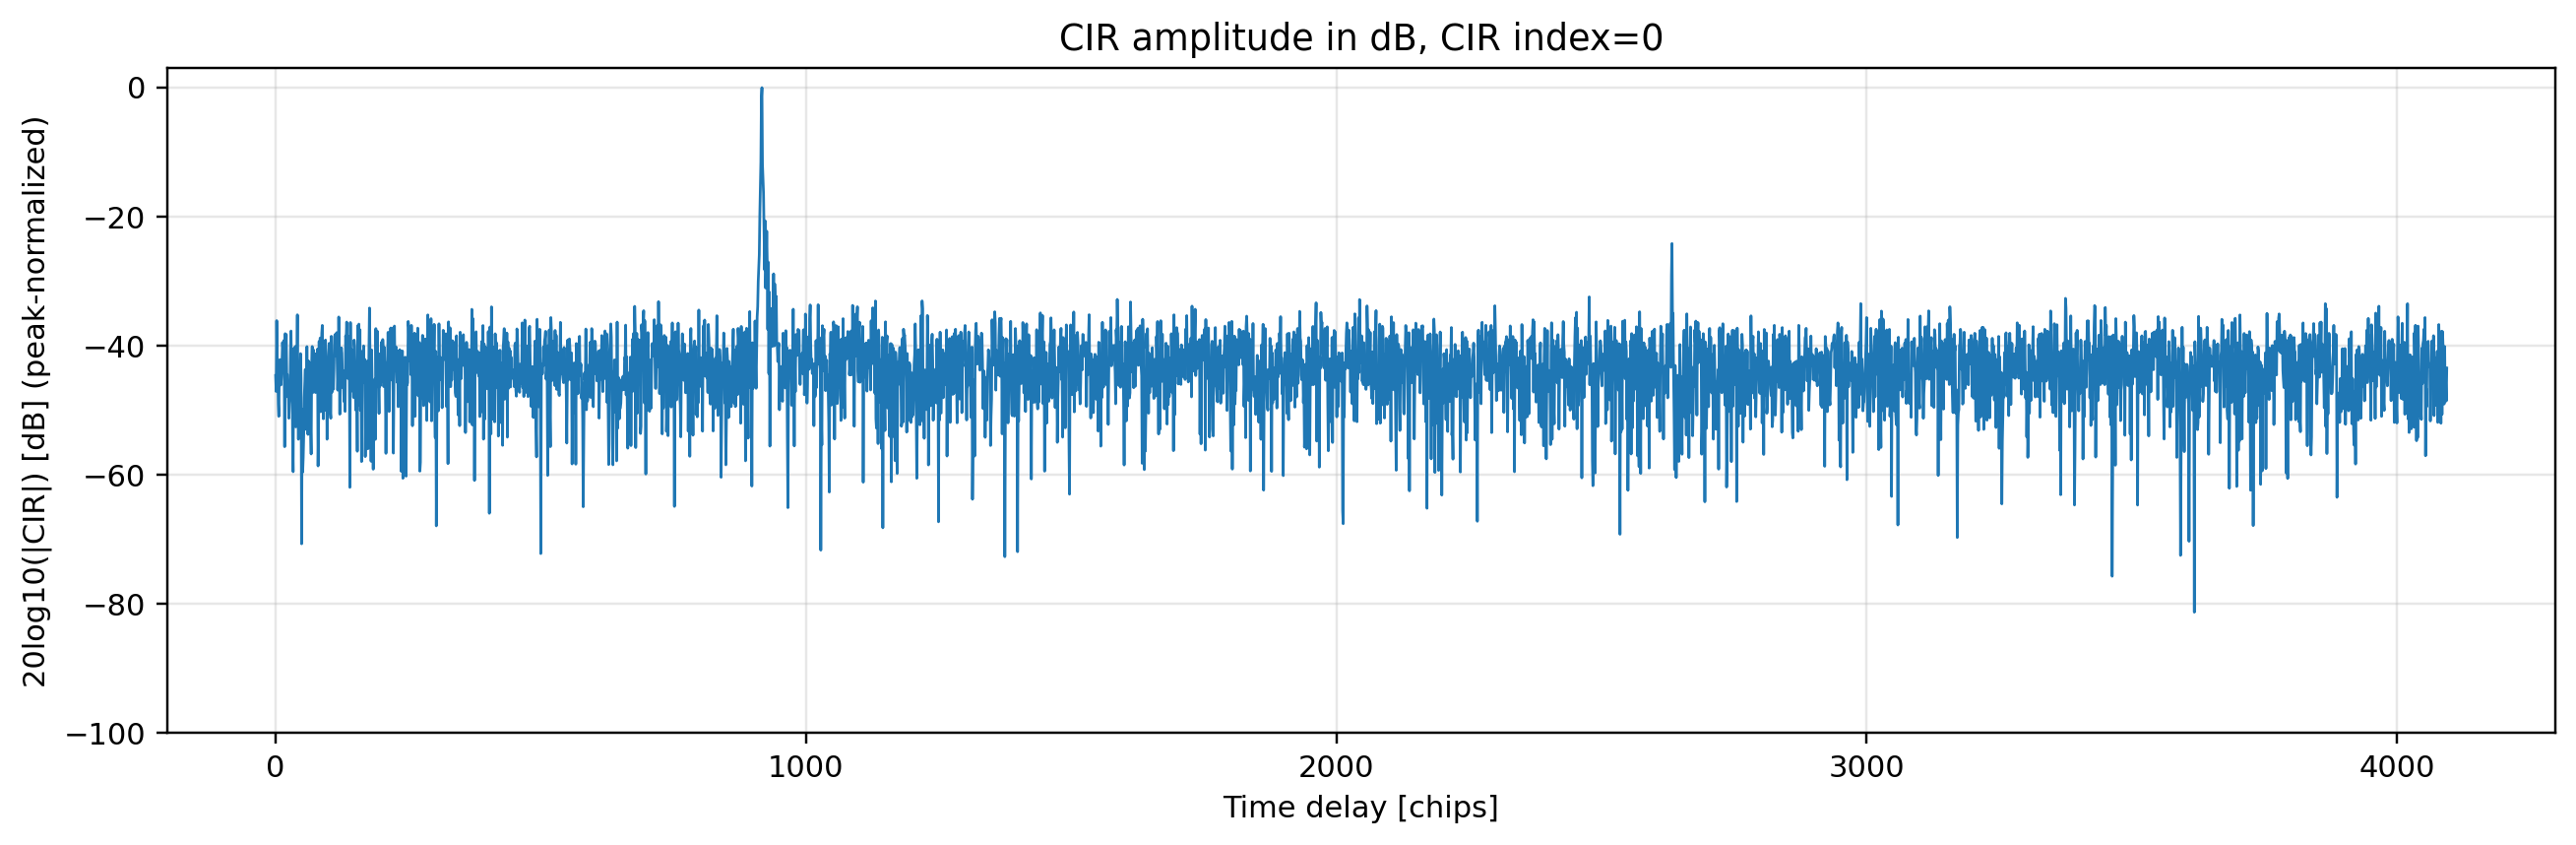

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

cir_key = "CIR"

chip_ns = 2.0
n_show = 0  # 0~280 중 보고 싶은 CIR 인덱스

mat = loadmat(mat_path)
cir = mat[cir_key].squeeze()

# (4095, 281) = (delay, CIR index)로 맞추기
if cir.shape[0] == 4095:
    cir_dn = cir
elif cir.shape[1] == 4095:
    cir_dn = np.swapaxes(cir, 0, 1)
else:
    raise ValueError(f"4095 축을 못 찾음: {cir.shape}")

D, N = cir_dn.shape
n_show = int(np.clip(n_show, 0, N-1))

delay_chips = np.arange(D)
delay_ns = delay_chips * chip_ns

# =========================
# 1) "CIR" 복소값 자체
# =========================
h = cir_dn[:, n_show]           # complex CIR, shape (4095,)
h_re = np.real(h)
h_im = np.imag(h)
h_mag = np.abs(h)
h_mag_db = 20*np.log10(np.maximum(h_mag, 1e-30))   # amplitude dB

print("CIR one-shot shape:", h.shape, "dtype:", h.dtype)
print("Example h[0]:", h[0])

# -------------------------
# Plot A: Re/Im (CIR)
# -------------------------
plt.figure(figsize=(12,4), dpi=220)
plt.plot(delay_chips, h_re, linewidth=0.9, label="Re{CIR}")
plt.plot(delay_chips, h_im, linewidth=0.9, label="Im{CIR}")
plt.grid(True, alpha=0.3)
plt.xlabel("Time delay [chips]")
plt.ylabel("CIR value (complex)")
plt.title(f"Complex CIR (Re/Im), CIR index={n_show}")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot B: |CIR| (magnitude)
# -------------------------
plt.figure(figsize=(12,4), dpi=220)
plt.plot(delay_chips, h_mag, linewidth=0.9)
plt.grid(True, alpha=0.3)
plt.xlabel("Time delay [chips]")
plt.ylabel("|CIR| (magnitude)")
plt.title(f"CIR magnitude, CIR index={n_show}")
plt.tight_layout()
plt.show()

# -------------------------
# Plot C: 20log10(|CIR|) (amplitude dB)
# -------------------------
h_mag_db_norm = h_mag_db - np.max(h_mag_db)  # 보기 편하게 peak=0 dB 정규화
plt.figure(figsize=(12,4), dpi=220)
plt.plot(delay_chips, h_mag_db_norm, linewidth=0.9)
plt.grid(True, alpha=0.3)
plt.xlabel("Time delay [chips]")
plt.ylabel("20log10(|CIR|) [dB] (peak-normalized)")
plt.title(f"CIR amplitude in dB, CIR index={n_show}")
plt.ylim(-100, 3)
plt.tight_layout()
plt.show()

# (옵션) ns 축으로도 보고 싶으면:
# plt.figure(figsize=(12,4), dpi=220)
# plt.plot(delay_ns, h_mag_db_norm, linewidth=0.9)
# plt.grid(True, alpha=0.3)
# plt.xlabel("Time delay [ns]")
# plt.ylabel("20log10(|CIR|) [dB] (peak-normalized)")
# plt.title(f"CIR amplitude in dB (ns axis), CIR index={n_show}")
# plt.ylim(-100, 3)
# plt.tight_layout()
# plt.show()


In [4]:
import numpy as np
from scipy.io import loadmat

# =========================
# 1) Load file
# =========================
mat_path = "/data/hw/cir_ws/data/HSV_3rd_SN1_FWD_PL_1x1_01/Rel_info.mat"
mat = loadmat(mat_path)

# =========================
# 2) Print keys
# =========================
keys = [k for k in mat.keys() if not k.startswith("__")]
print("MAT keys:")
for k in keys:
    print(" -", k)

print("\n==============================\n")

# =========================
# 3) Inspect each variable
# =========================
for k in keys:
    v = mat[k]
    print(f"Variable: {k}")
    print("  Type  :", type(v))

    if isinstance(v, np.ndarray):
        print("  Shape :", v.shape)
        print("  Dtype :", v.dtype)

        # 숫자 배열이면 통계 출력
        if np.issubdtype(v.dtype, np.number):
            try:
                print("  Min   :", np.min(v))
                print("  Max   :", np.max(v))
                print("  Mean  :", np.mean(v))
            except:
                pass

        # 너무 크면 앞부분만 보기
        if v.size < 20:
            print("  Values:", v)
        else:
            print("  Sample values:", v.flatten()[:10])

    print("------------------------------")


MAT keys:
 - CIR_flag
 - rx_header
 - rx_daqheader
 - AGC
 - RSSI


Variable: CIR_flag
  Type  : <class 'numpy.ndarray'>
  Shape : (1, 1)
  Dtype : [('overwrite', 'O'), ('save_CIR', 'O'), ('save_CIR_WS', 'O'), ('save_CIR_raw', 'O')]
  Values: [[(array([[1]], dtype=uint8), array([[1]], dtype=uint8), array([[1]], dtype=uint8), array([[0]], dtype=uint8))]]
------------------------------
Variable: rx_header
  Type  : <class 'numpy.ndarray'>
  Shape : (1, 1)
  Dtype : [('oversample', 'O'), ('num_taps', 'O'), ('file_header_size', 'O'), ('daq_header_size', 'O'), ('adc_bits', 'O'), ('adc_input_range', 'O'), ('adc_scale_factor', 'O'), ('pathname', 'O'), ('filename', 'O'), ('file_type_hex', 'O'), ('file_version', 'O'), ('date', 'O'), ('time', 'O'), ('freq_MHz', 'O'), ('band', 'O'), ('chiprate', 'O'), ('cs_mode', 'O'), ('cs_id', 'O'), ('tx_map', 'O'), ('rx_map', 'O'), ('num_tx', 'O'), ('num_rx', 'O'), ('code_type', 'O'), ('pn_period', 'O'), ('pn_order', 'O'), ('pn_poly_oct', 'O'), ('pn_per_rx', '

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

def _todict(matobj):
    """scipy.io.loadmat로 읽힌 MATLAB struct를 파이썬 dict로 변환"""
    d = {}
    for fieldname in matobj._fieldnames:
        elem = getattr(matobj, fieldname)
        if hasattr(elem, "_fieldnames"):
            d[fieldname] = _todict(elem)
        else:
            d[fieldname] = elem
    return d

def load_mat_safely(mat_path):
    """
    MATLAB v7.2 이하: scipy.io.loadmat
    MATLAB v7.3(HDF5): h5py로 fallback
    """
    try:
        data = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
        # struct 변환
        for k, v in list(data.items()):
            if hasattr(v, "_fieldnames"):
                data[k] = _todict(v)
        return data
    except NotImplementedError:
        import h5py
        out = {}
        with h5py.File(mat_path, "r") as f:
            def read_item(obj):
                if isinstance(obj, h5py.Dataset):
                    arr = obj[()]
                    # MATLAB char / scalar 처리
                    if arr.dtype.kind in ("S", "O"):
                        try:
                            return arr.astype(str)
                        except Exception:
                            return arr
                    return arr
                elif isinstance(obj, h5py.Group):
                    return {kk: read_item(obj[kk]) for kk in obj.keys()}
                else:
                    return obj

            for k in f.keys():
                out[k] = read_item(f[k])
        return out

DATA_DIR = "/data/hw/cir_ws/data/HSV_3rd_SN1_FWD_PL_1x1_01/"
CIR_MAT = os.path.join(DATA_DIR, "CIR.mat")
REL_MAT = os.path.join(DATA_DIR, "Rel_info.mat")

print("CIR exists:", os.path.exists(CIR_MAT), CIR_MAT)
print("REL exists:", os.path.exists(REL_MAT), REL_MAT)

CIR exists: True /data/hw/cir_ws/data/HSV_3rd_SN1_FWD_PL_1x1_01/CIR.mat
REL exists: True /data/hw/cir_ws/data/HSV_3rd_SN1_FWD_PL_1x1_01/Rel_info.mat


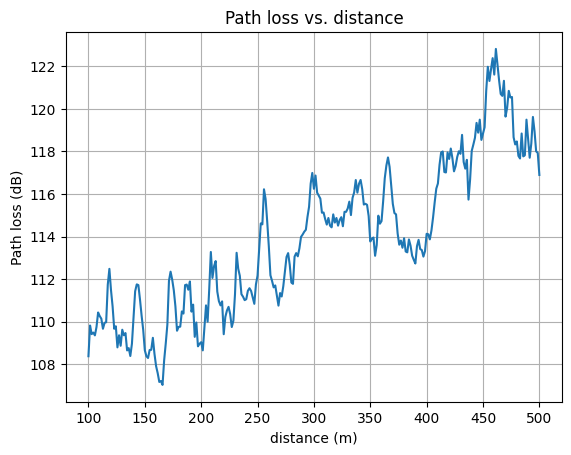

PL shape: (281,) min/max: 107.03127484355537 122.81301334810192


In [6]:
cir_data = load_mat_safely(CIR_MAT)
rel_data = load_mat_safely(REL_MAT)

# ---- CIR 읽기 ----
# MATLAB: CIR = squeeze(CIR)
CIR = cir_data.get("CIR", None)
if CIR is None:
    raise KeyError("CIR.mat 안에 'CIR' 변수가 없습니다.")

CIR = np.array(CIR)
CIR = np.squeeze(CIR)

# 케이스1) 이미 (4095, Nsnap) 형태
# 케이스2) 원본 DS 코드처럼 5차원일 수도 있음: (4095, link, frame, cycle, daq)
# PL 코드는 (4095, snapshot)처럼 다루므로 snapshot 축으로 펼침
if CIR.ndim == 2:
    CIR_2d = CIR  # (delay, snapshot)
else:
    # delay 축을 제외한 나머지를 전부 snapshot으로 flatten
    if CIR.shape[0] != 4095:
        # 혹시 축 순서가 다를 경우 대비: delay가 4095인 축 찾기
        delay_axis = int(np.where(np.array(CIR.shape) == 4095)[0][0])
        CIR = np.moveaxis(CIR, delay_axis, 0)
    CIR_2d = CIR.reshape(CIR.shape[0], -1)

# ---- AGC / RSSI 읽기 ----
# MATLAB: AGC = [rx_daqheader.rx_atten]
rx_daqheader = rel_data.get("rx_daqheader", None)
if rx_daqheader is None:
    raise KeyError("Rel_info.mat 안에 'rx_daqheader'가 없습니다.")

# rx_daqheader가 struct array면 dict/list/ndarray 등 다양한 형태 가능
# 최대한 robust하게 rx_atten을 뽑는다
def extract_rx_atten(rx_daqheader_obj):
    # dict 형태
    if isinstance(rx_daqheader_obj, dict):
        ra = rx_daqheader_obj.get("rx_atten", None)
        if ra is None:
            raise KeyError("rx_daqheader 안에 'rx_atten'이 없습니다.")
        return np.ravel(np.array(ra)).astype(float)

    # numpy object array (struct array)
    if isinstance(rx_daqheader_obj, np.ndarray) and rx_daqheader_obj.dtype == object:
        vals = []
        for el in rx_daqheader_obj.ravel():
            if isinstance(el, dict) and "rx_atten" in el:
                vals.append(float(np.array(el["rx_atten"]).squeeze()))
            elif hasattr(el, "get") and el.get("rx_atten", None) is not None:
                vals.append(float(np.array(el.get("rx_atten")).squeeze()))
            else:
                # scipy struct object
                if hasattr(el, "rx_atten"):
                    vals.append(float(np.array(el.rx_atten).squeeze()))
                else:
                    raise ValueError("rx_daqheader 원소에서 rx_atten을 찾지 못했습니다.")
        return np.array(vals, dtype=float)

    # scipy struct object
    if hasattr(rx_daqheader_obj, "rx_atten"):
        return np.ravel(np.array(rx_daqheader_obj.rx_atten)).astype(float)

    raise TypeError(f"rx_daqheader 타입을 처리할 수 없습니다: {type(rx_daqheader_obj)}")

AGC = extract_rx_atten(rx_daqheader)

RSSI = rel_data.get("RSSI", None)
if RSSI is None:
    # 파일마다 rssi 변수명이 다를 수 있어서 후보를 좀 본다
    for cand in ["rssi", "Rx_RSSI", "rx_rssi", "RSSI_dB"]:
        if cand in rel_data:
            RSSI = rel_data[cand]
            break
if RSSI is None:
    raise KeyError("Rel_info.mat 안에 'RSSI' (또는 유사 변수)를 찾지 못했습니다.")
RSSI = np.ravel(np.array(RSSI)).astype(float)

# snapshot 개수 정합
Nsnap = CIR_2d.shape[1]
if len(AGC) != Nsnap:
    print(f"[경고] AGC 길이({len(AGC)})와 CIR snapshot({Nsnap})가 다릅니다. 가능한 범위로 맞춥니다.")
    M = min(len(AGC), Nsnap, len(RSSI))
    AGC = AGC[:M]
    RSSI = RSSI[:M]
    CIR_2d = CIR_2d[:, :M]
    Nsnap = M
else:
    if len(RSSI) != Nsnap:
        print(f"[경고] RSSI 길이({len(RSSI)})와 CIR snapshot({Nsnap})가 다릅니다. 가능한 범위로 맞춥니다.")
        M = min(len(RSSI), Nsnap)
        RSSI = RSSI[:M]
        AGC = AGC[:M]
        CIR_2d = CIR_2d[:, :M]
        Nsnap = M

# ---- MATLAB과 동일한 보정/shift ----
CIR_corr = CIR_2d.astype(np.complex128).copy()
CIR_shift = np.zeros_like(CIR_corr)

for i in range(Nsnap):
    cir_this = CIR_corr[:, i] * (10 ** (AGC[i] / 20.0))
    CIR_corr[:, i] = cir_this
    max_i = int(np.argmax(np.abs(cir_this)))
    shift = 1 - (max_i + 1)  # MATLAB 1-index -> Python 0-index 보정
    CIR_shift[:, i] = np.roll(cir_this, shift)

# ---- 파라미터(원본 MATLAB 값) ----
Par = {}
Par["TX_power"] = 26.5
Par["TX_ant_gain"] = 13
Par["RX_ant_gain"] = 3
Par["RX_sys_gain"] = 76.67
Par["PDP_offset"] = -8.5146
Par["delay_resolution"] = 2e-9
Par["delay"] = np.arange(0, 4095) * Par["delay_resolution"]
Par["AGC"] = AGC
Par["RSSI"] = RSSI

# MATLAB: Par.noise_power = 4095*mean(abs(CIR_shift(3276:3890,:)).^2)
# MATLAB index 3276:3890 (1-index) -> Python 3275:3890 (0-index, 끝은 exclusive라 +0)
noise_slice = slice(3275, 3890)
Par["noise_power"] = 4095.0 * np.mean(np.abs(CIR_shift[noise_slice, :]) ** 2)

# MATLAB: Par.distance = linspace(500,100,length(RSSI))
Par["distance"] = np.linspace(500.0, 100.0, Nsnap)

# MATLAB: RX_power = 10*log10( sum(abs(CIR).^2) - noise_power ) + PDP_offset
sig_pow = np.sum(np.abs(CIR_corr) ** 2, axis=0) - Par["noise_power"]
sig_pow = np.maximum(sig_pow, 1e-30)  # log 안전장치
RX_power = 10.0 * np.log10(sig_pow) + Par["PDP_offset"]

# MATLAB: PL = (TX+TXant) - (RX - RXsys - RXant)
PL = (Par["TX_power"] + Par["TX_ant_gain"]) - (RX_power - Par["RX_sys_gain"] - Par["RX_ant_gain"])
Par["PL"] = PL

# ---- 결과 플롯 ----
plt.figure()
plt.plot(Par["distance"], PL)
plt.grid(True)
plt.title("Path loss vs. distance")
plt.xlabel("distance (m)")
plt.ylabel("Path loss (dB)")
plt.show()

print("PL shape:", PL.shape, "min/max:", float(np.nanmin(PL)), float(np.nanmax(PL)))

CIR shape: (4095, 281)  (delay + others)
DS computed. total: 281 nan: 0


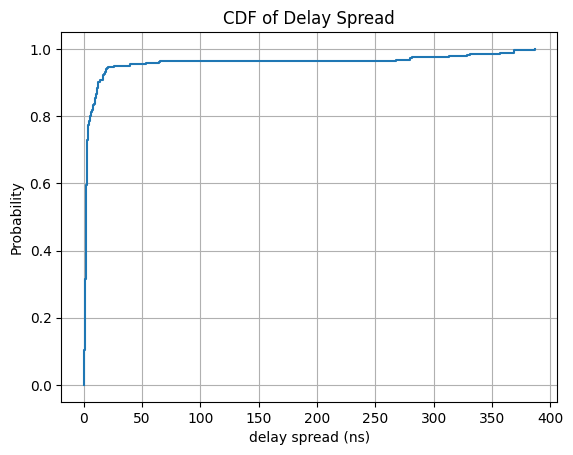

In [7]:
rel_data = load_mat_safely(REL_MAT)
cir_data = load_mat_safely(CIR_MAT)

CIR = np.array(cir_data["CIR"])
CIR = np.squeeze(CIR)

rx_header = rel_data.get("rx_header", None)
if rx_header is None:
    raise KeyError("Rel_info.mat 안에 'rx_header'가 없습니다.")

# chiprate 읽기 (MATLAB: rx_header.chiprate)
def get_field(d, name):
    if isinstance(d, dict):
        return d.get(name, None)
    if hasattr(d, name):
        return getattr(d, name)
    return None

chiprate = get_field(rx_header, "chiprate")
if chiprate is None:
    raise KeyError("rx_header 안에 'chiprate'가 없습니다.")
chiprate = float(np.array(chiprate).squeeze())

# DS_setting (원본 MATLAB 값)
noise_range = np.array([0.7, 0.95], dtype=float)
threshold_NF_add = 3.0
threshold_PP_drop = 20.0

# CIR이 5차원인지 확인: (delay, link, frame, cycle, daq)
if CIR.ndim < 2:
    raise ValueError("CIR 차원이 너무 낮습니다. DS 계산이 불가능합니다.")

# delay 축 정렬 (4095인 축을 앞으로)
if CIR.shape[0] != 4095:
    delay_axis = int(np.where(np.array(CIR.shape) == 4095)[0][0])
    CIR = np.moveaxis(CIR, delay_axis, 0)

# 나머지 축 이름 유추 (원본: link, frame, cycle, daq)
# 실제 파일에 따라 축이 다를 수 있어서, 일단 delay 제외한 축을 그대로 사용
rest_shape = CIR.shape[1:]
print("CIR shape:", CIR.shape, " (delay + others)")

# 2D로 펼쳐서 'snapshot' 단위로 DS 계산 (MATLAB은 모든 인덱스 loop)
CIR_flat = CIR.reshape(4095, -1)

DS_list = []
DS_nan_count = 0

for s in range(CIR_flat.shape[1]):
    cir_this = CIR_flat[:, s]
    PDP = np.abs(cir_this)**2
    max_i = int(np.argmax(PDP))  # 0-index

    # MATLAB: noise_range = max_i + round(length(PDP)*noise_range)-1
    nr = max_i + np.round(len(PDP) * noise_range).astype(int) - 1
    nr = np.clip(nr, 0, len(PDP)-1)

    # MATLAB: PDP_shift = circshift(PDP, length(PDP)-noise_range(2))
    shift = len(PDP) - nr[1]
    PDP_shift = np.roll(PDP, shift)

    # MATLAB: noise_idx = [length(PDP)-(noise_range(2)-noise_range(1)):length(PDP)]
    noise_len = (nr[1] - nr[0])
    start = len(PDP) - noise_len
    start = max(start, 0)
    noise_idx = np.arange(start, len(PDP))

    PDP_dB = 10*np.log10(np.maximum(PDP_shift, 1e-30))
    PDP_dB = PDP_dB - np.max(PDP_dB)

    thr_nf = np.max(PDP_dB[noise_idx]) + threshold_NF_add
    thr_pp = np.max(PDP_dB) - threshold_PP_drop
    thr = max(thr_nf, thr_pp)

    mask = PDP_dB > thr
    if not np.any(mask):
        DS_list.append(np.nan)
        DS_nan_count += 1
        continue

    delay = (np.where(mask)[0] + 1) / chiprate  # MATLAB find는 1-index 느낌이라 +1 맞춤
    power = PDP_shift[mask]

    T_D = np.sum(power * delay) / np.sum(power)
    sigma = np.sqrt(np.sum(power * (delay - T_D)**2) / np.sum(power))

    # MATLAB: if threshold_NF > threshold_PP => NaN
    if thr_nf > thr_pp:
        sigma = np.nan
        DS_nan_count += 1

    DS_list.append(sigma)

DS_arr = np.array(DS_list, dtype=float)
print("DS computed. total:", DS_arr.size, "nan:", int(np.isnan(DS_arr).sum()))

# CDF (ns)
CDF_x = DS_arr[~np.isnan(DS_arr)] * 1e9
CDF_x = np.sort(CDF_x)
CDF_y = np.arange(1, len(CDF_x)+1) / len(CDF_x)

# MATLAB 스타일의 step CDF 만들기
CDF_x_step = np.repeat(CDF_x, 2)
CDF_y_step = np.repeat(CDF_y, 2)
CDF_y_step = np.concatenate([[0.0], CDF_y_step[:-1]])

plt.figure()
plt.plot(CDF_x_step, CDF_y_step)
plt.grid(True)
plt.title("CDF of Delay Spread")
plt.xlabel("delay spread (ns)")
plt.ylabel("Probability")
plt.show()

Done. cir_nlos_all shape: (4095, 281)


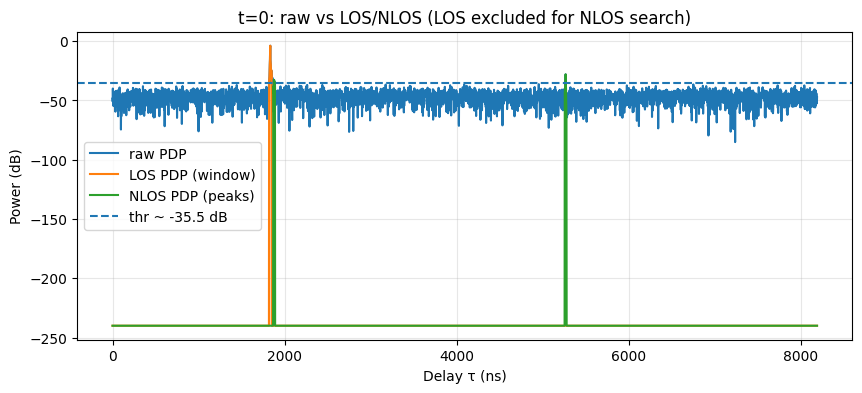

t=0 tau_LOS≈1834.0 ns, noise≈-45.5 dB, thr≈-35.5 dB


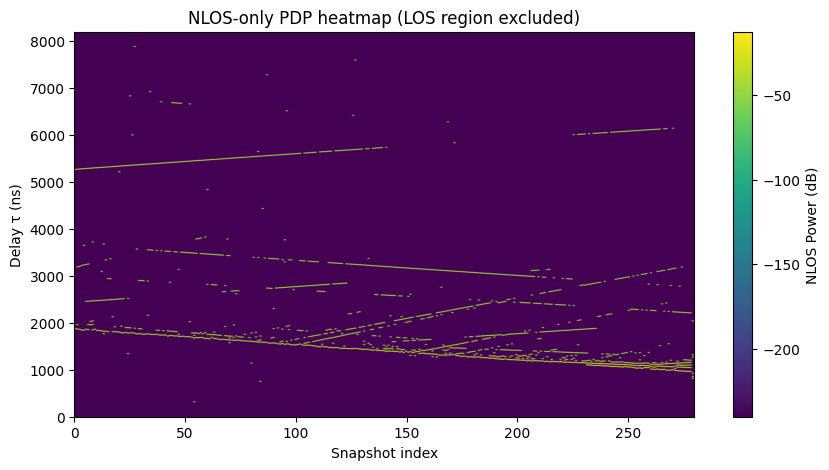

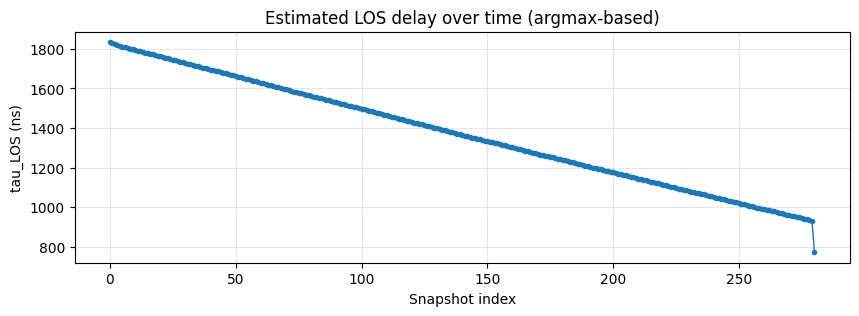

In [8]:
# =========================
# (NEW) LOS 주변 전이/사이드로브 제외 + NLOS 추출 (snapshot별)
#   - tail로 noise floor 추정(바닥)
#   - LOS(최대 피크) 주변은 전이/사이드로브로 보고 제외(exclusion)
#   - 남은 구간에서 threshold + top-K 피크로 NLOS만 남김
# =========================
import numpy as np
import matplotlib.pyplot as plt

# ---- 파라미터 (필요시 여기만 조절) ----
TAIL_RATIO = 0.15            # delay 뒤쪽 15%로 noise floor 추정
THR_ABOVE_NOISE_DB = 10.0    # noise + 10dB 이상만 후보
LOS_WINDOW_NS = 15.0         # LOS 피크 주변(앞쪽) 제외 폭 (±)
GUARD_NS = 30.0              # LOS 이후 전이/사이드로브 제외 길이
TOPK_NLOS = 6                # NLOS 피크 개수
PEAK_WINDOW_NS = 10.0        # 각 피크 주변 윈도우(±)만 남김
MIN_SEP_NS = 40.0            # 피크 간 최소 간격

def pick_peaks_topk(P_db, tau_ns, min_sep_ns=40.0, topk=6):
    Nd = len(P_db)
    cand = np.where((P_db[1:-1] > P_db[:-2]) & (P_db[1:-1] > P_db[2:]))[0] + 1
    if cand.size == 0:
        return np.array([], dtype=int)
    cand = cand[np.argsort(P_db[cand])[::-1]]
    picked = []
    for i in cand:
        if len(picked) >= topk:
            break
        if all(abs(tau_ns[i] - tau_ns[j]) >= min_sep_ns for j in picked):
            picked.append(i)
    return np.array(picked, dtype=int)

def extract_los_nlos_snapshot(cir_t, tau_ns,
                             tail_ratio=0.15,
                             thr_above_noise_db=10.0,
                             los_window_ns=15.0,
                             guard_ns=30.0,
                             topk_nlos=6,
                             peak_window_ns=10.0,
                             min_sep_ns=40.0):
    """한 스냅샷에서 노이즈 바닥 추정 + LOS 제외 + NLOS 피크만 남긴 CIR 반환"""
    Nd = len(cir_t)
    P = np.abs(cir_t)**2
    P_db = 10*np.log10(np.maximum(P, 1e-24))

    # noise floor (tail)
    tail_start = int((1.0 - tail_ratio) * Nd)
    noise_power = float(np.mean(P[tail_start:]))
    noise_power = max(noise_power, 1e-24)
    noise_db = 10*np.log10(noise_power)
    thr_db = noise_db + thr_above_noise_db

    # LOS 후보: 최대 피크(가장 강한 경로)
    i_los = int(np.argmax(P))
    tau_los = float(tau_ns[i_los])

    # LOS 주변/이후 전이 구간 제외
    exclude = (tau_ns >= (tau_los - los_window_ns)) & (tau_ns <= (tau_los + guard_ns))

    # 후보: threshold 이상 & exclude 밖
    cand_db = P_db.copy()
    cand_db[(P_db < thr_db) | exclude] = -1e9

    # NLOS 피크 선택
    peak_idx = pick_peaks_topk(cand_db, tau_ns, min_sep_ns=min_sep_ns, topk=topk_nlos)

    # NLOS mask: 선택된 피크 주변만
    nlos_mask = np.zeros(Nd, dtype=bool)
    for i in peak_idx:
        nlos_mask |= (tau_ns >= tau_ns[i]-peak_window_ns) & (tau_ns <= tau_ns[i]+peak_window_ns)

    # LOS mask(참고용): LOS 피크 주변만
    los_mask = (tau_ns >= (tau_los - los_window_ns)) & (tau_ns <= (tau_los + los_window_ns))

    cir_los = cir_t * los_mask
    cir_nlos = cir_t * nlos_mask
    cir_valid = cir_t * (P_db >= thr_db)  # 단순 threshold 통과분(전이/사이드로브 포함 가능)

    return {
        'cir_valid': cir_valid,
        'cir_los': cir_los,
        'cir_nlos': cir_nlos,
        'tau_los_ns': tau_los,
        'noise_db': noise_db,
        'thr_db': thr_db,
        'peak_idx': peak_idx,
        'exclude_mask': exclude,
    }

# ---- 전체 281개에 대해 NLOS/LOS 추출 ----
Nd, Nt = cir_dn.shape
tau_ns = delay_ns  # 기존 노트북 변수명 유지

cir_los_all  = np.zeros_like(cir_dn)
cir_nlos_all = np.zeros_like(cir_dn)
tau_los_all = np.full((Nt,), np.nan)
thr_db_all = np.full((Nt,), np.nan)
noise_db_all = np.full((Nt,), np.nan)

for t in range(Nt):
    out = extract_los_nlos_snapshot(
        cir_dn[:, t], tau_ns,
        tail_ratio=TAIL_RATIO,
        thr_above_noise_db=THR_ABOVE_NOISE_DB,
        los_window_ns=LOS_WINDOW_NS,
        guard_ns=GUARD_NS,
        topk_nlos=TOPK_NLOS,
        peak_window_ns=PEAK_WINDOW_NS,
        min_sep_ns=MIN_SEP_NS,
    )
    cir_los_all[:, t]  = out['cir_los']
    cir_nlos_all[:, t] = out['cir_nlos']
    tau_los_all[t] = out['tau_los_ns']
    thr_db_all[t] = out['thr_db']
    noise_db_all[t] = out['noise_db']

print('Done. cir_nlos_all shape:', cir_nlos_all.shape)

# ---- 확인 플롯: 원하는 스냅샷 1개 ----
t = n_show  # 위에서 선택한 스냅샷 번호 재사용
eps = 1e-24
P_raw_db  = 10*np.log10(np.maximum(np.abs(cir_dn[:,t])**2, eps))
P_los_db  = 10*np.log10(np.maximum(np.abs(cir_los_all[:,t])**2, eps))
P_nlos_db = 10*np.log10(np.maximum(np.abs(cir_nlos_all[:,t])**2, eps))

plt.figure(figsize=(10,4))
plt.plot(tau_ns, P_raw_db, label='raw PDP')
plt.plot(tau_ns, P_los_db, label='LOS PDP (window)')
plt.plot(tau_ns, P_nlos_db, label='NLOS PDP (peaks)')
plt.axhline(thr_db_all[t], linestyle='--', label=f"thr ~ {thr_db_all[t]:.1f} dB")
plt.xlabel('Delay τ (ns)')
plt.ylabel('Power (dB)')
plt.title(f't={t}: raw vs LOS/NLOS (LOS excluded for NLOS search)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"t={t} tau_LOS≈{tau_los_all[t]:.1f} ns, noise≈{noise_db_all[t]:.1f} dB, thr≈{thr_db_all[t]:.1f} dB")

# ---- heatmap (NLOS만) ----
A = 10*np.log10(np.maximum(np.abs(cir_nlos_all)**2, 1e-24))
plt.figure(figsize=(10,5))
plt.imshow(A, aspect='auto', origin='lower', extent=[0, Nt-1, tau_ns[0], tau_ns[-1]])
plt.colorbar(label='NLOS Power (dB)')
plt.xlabel('Snapshot index')
plt.ylabel('Delay τ (ns)')
plt.title('NLOS-only PDP heatmap (LOS region excluded)')
plt.show()

# ---- LOS 지연 추적 ----
plt.figure(figsize=(10,3))
plt.plot(tau_los_all, marker='.', linewidth=1)
plt.xlabel('Snapshot index')
plt.ylabel('tau_LOS (ns)')
plt.title('Estimated LOS delay over time (argmax-based)')
plt.grid(True, alpha=0.3)
plt.show()


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# -------------------------
# peak 선택 유틸
# -------------------------
def pick_peaks_topk(P_db, tau_ns, min_sep_ns=40.0, topk=6):
    cand = np.where((P_db[1:-1] > P_db[:-2]) & (P_db[1:-1] > P_db[2:]))[0] + 1
    if cand.size == 0:
        return np.array([], dtype=int)
    cand = cand[np.argsort(P_db[cand])[::-1]]
    picked = []
    for i in cand:
        if len(picked) >= topk:
            break
        if all(abs(tau_ns[i] - tau_ns[j]) >= min_sep_ns for j in picked):
            picked.append(i)
    return np.array(picked, dtype=int)

# -------------------------
# 핵심: 특정 t에서 LOS/threshold/NLOS peaks를 "현재 파라미터"로 계산
# -------------------------
def compute_los_nlos_at_t(t, cir_dn, tau_ns,
                         tail_ratio=0.15,
                         thr_above_noise_db=10.0,
                         los_window_ns=15.0,
                         guard_ns=30.0,
                         topk_nlos=6,
                         min_sep_ns=40.0,
                         peak_window_ns=10.0):
    eps = 1e-24
    Nd = cir_dn.shape[0]

    # power / dB
    P = np.abs(cir_dn[:, t])**2
    P_db = 10*np.log10(np.maximum(P, eps))

    # magnitude (linear, 상대단위)
    H_mag = np.abs(cir_dn[:, t])

    # noise from tail
    tail_start = int((1.0 - tail_ratio) * Nd)
    noise_power = max(np.mean(P[tail_start:]), eps)
    noise_db = 10*np.log10(noise_power)
    thr_db = noise_db + thr_above_noise_db

    # LOS: argmax
    i_los = int(np.argmax(P))
    tau_los = float(tau_ns[i_los])

    LOS_power_dB = float(P_db[i_los])
    LOS_mag = float(H_mag[i_los])

    # exclude LOS+transition
    exclude = (tau_ns >= (tau_los - los_window_ns)) & (tau_ns <= (tau_los + guard_ns))

    # candidate for NLOS
    cand_db = P_db.copy()
    cand_db[(P_db < thr_db) | exclude] = -1e9

    peak_idx = pick_peaks_topk(cand_db, tau_ns, min_sep_ns=min_sep_ns, topk=int(topk_nlos))
    nlos_taus = tau_ns[peak_idx].astype(float).tolist()

    # NLOS 피크 power/mag 리스트 (표에 넣을 값)
    NLOS_powers_db = [float(P_db[i]) for i in peak_idx]
    NLOS_mags = [float(H_mag[i]) for i in peak_idx]

    # 그래프용 mask (선택)
    nlos_mask = np.zeros_like(tau_ns, dtype=bool)
    for i in peak_idx:
        nlos_mask |= (tau_ns >= tau_ns[i]-peak_window_ns) & (tau_ns <= tau_ns[i]+peak_window_ns)

    los_mask = (tau_ns >= tau_los - los_window_ns) & (tau_ns <= tau_los + los_window_ns)

    return {
        "P_db": P_db,
        "H_mag": H_mag,

        "tau_los": tau_los,
        "LOS_power_dB": LOS_power_dB,
        "LOS_mag": LOS_mag,

        "noise_db": noise_db,
        "thr_db": thr_db,

        "nlos_taus": nlos_taus,
        "NLOS_powers_db": NLOS_powers_db,
        "NLOS_mags": NLOS_mags,

        "los_mask": los_mask,
        "nlos_mask": nlos_mask,
        "exclude_left": tau_los - los_window_ns,
        "exclude_right": tau_los + guard_ns
    }

# -------------------------
# 시간축(추정) : 400m / 100kmh 기반
# -------------------------
Nt = cir_dn.shape[1]
v_mps = 100_000/3600
total_dist_m = 400.0
total_time_s = total_dist_m / v_mps
dt_s = total_time_s / (Nt-1)
time_s = np.arange(Nt) * dt_s
dist_m = np.arange(Nt) * (total_dist_m/(Nt-1))

# -------------------------
# UI
# -------------------------
t_slider   = widgets.IntSlider(value=0, min=0, max=Nt-1, step=1, description="t")
los_slider = widgets.FloatSlider(value=15.0, min=2.0, max=150.0, step=1.0, description="LOS win")
g_slider   = widgets.FloatSlider(value=30.0, min=0.0, max=500.0, step=5.0, description="guard")
thr_slider = widgets.FloatSlider(value=10.0, min=0.0, max=30.0, step=1.0, description="thr+(dB)")

# (고급 파라미터는 기본 고정)
tail_ratio = 0.15
topk_nlos = 6
min_sep_ns = 40.0
peak_window_ns = 10.0

out_plot = widgets.Output()
out_table = widgets.Output()

# 기록 기능(선택)
save_btn = widgets.Button(description="이 t 저장", button_style="")
clear_btn = widgets.Button(description="기록 초기화", button_style="warning")
out_saved = widgets.Output()
saved_rows = []

def render(t):
    res = compute_los_nlos_at_t(
        t=t,
        cir_dn=cir_dn,
        tau_ns=tau_ns,
        tail_ratio=tail_ratio,
        thr_above_noise_db=thr_slider.value,
        los_window_ns=los_slider.value,
        guard_ns=g_slider.value,
        topk_nlos=topk_nlos,
        min_sep_ns=min_sep_ns,
        peak_window_ns=peak_window_ns
    )

    # ---- plot ----
    with out_plot:
        clear_output(wait=True)
        plt.figure(figsize=(10,4))
        plt.plot(tau_ns, res["P_db"], label="raw PDP")

        P_los = np.full_like(res["P_db"], np.nan)
        P_los[res["los_mask"]] = res["P_db"][res["los_mask"]]

        P_nlos = np.full_like(res["P_db"], np.nan)
        P_nlos[res["nlos_mask"]] = res["P_db"][res["nlos_mask"]]

        plt.plot(tau_ns, P_los, linewidth=2, label="LOS (window)")
        plt.plot(tau_ns, P_nlos, linewidth=2, label="NLOS (peaks window)")

        if len(res["nlos_taus"]) > 0:
            idx = [int(np.argmin(np.abs(tau_ns-x))) for x in res["nlos_taus"]]
            plt.scatter([tau_ns[i] for i in idx], [res["P_db"][i] for i in idx], s=50, label="NLOS peaks")

        plt.axhline(res["thr_db"], linestyle="--",
                    label=f"thr=noise({res['noise_db']:.1f})+{thr_slider.value:.1f}dB")
        plt.axvspan(res["exclude_left"], res["exclude_right"], alpha=0.15, label="excluded")
        plt.title(f"t={t}")
        plt.xlabel("Delay τ (ns)")
        plt.ylabel("Power (dB)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    # ---- table (현재 t 한 줄) ----
    peaks = res["nlos_taus"]
    pows  = res["NLOS_powers_db"]
    mags  = res["NLOS_mags"]

    row = {
        "snapshot": t,
        "time_s(estimated)": float(time_s[t]),
        "dist_m(estimated)": float(dist_m[t]),

        "tau_LOS_ns": float(res["tau_los"]),
        "LOS_power_dB": float(res["LOS_power_dB"]),
        "LOS_|CIR|": float(res["LOS_mag"]),

        "noise_db": float(res["noise_db"]),
        "thr_db": float(res["thr_db"]),

        "NLOS_peak1_ns": peaks[0] if len(peaks) > 0 else np.nan,
        "NLOS_p1_dB":    pows[0]  if len(pows)  > 0 else np.nan,
        "NLOS_|CIR|_1":  mags[0]  if len(mags)  > 0 else np.nan,

        "NLOS_peak2_ns": peaks[1] if len(peaks) > 1 else np.nan,
        "NLOS_p2_dB":    pows[1]  if len(pows)  > 1 else np.nan,
        "NLOS_|CIR|_2":  mags[1]  if len(mags)  > 1 else np.nan,

        "NLOS_peak3_ns": peaks[2] if len(peaks) > 2 else np.nan,
        "NLOS_p3_dB":    pows[2]  if len(pows)  > 2 else np.nan,
        "NLOS_|CIR|_3":  mags[2]  if len(mags)  > 2 else np.nan,

        "NLOS_peaks_all_ns": str(peaks),
        "NLOS_powers_all_dB": str([round(x,2) for x in pows]),
        "NLOS_|CIR|_all": str([round(x,6) for x in mags]),
    }

    from IPython.display import HTML

    with out_table:
        clear_output(wait=True)
        df_row = pd.DataFrame([row])

        html = df_row.to_html(index=False)  # jinja2 필요 없음
        display(HTML(f"""
        <div style="overflow-x:auto; white-space:nowrap; border:1px solid #ddd; padding:6px;">
        {html}
        </div>
        """))

    return row

def update(_=None):
    render(t_slider.value)

def on_save(_):
    row = render(t_slider.value)
    saved_rows.append(row)
    with out_saved:
        clear_output(wait=True)
        display(pd.DataFrame(saved_rows))

def on_clear(_):
    saved_rows.clear()
    with out_saved:
        clear_output(wait=True)
        print("기록이 초기화됨")

save_btn.on_click(on_save)
clear_btn.on_click(on_clear)

for w in [t_slider, los_slider, g_slider, thr_slider]:
    w.observe(update, names="value")

display(widgets.VBox([
    widgets.HBox([t_slider, los_slider, g_slider, thr_slider]),
    out_plot,
    widgets.HTML("<b>현재 t의 LOS/NLOS 위치 + 크기(표)</b>"),
    out_table,
    widgets.HBox([save_btn, clear_btn]),
    widgets.HTML("<b>저장된 기록(누적)</b>"),
    out_saved
]))
update()

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# -------------------------
# peak 선택 유틸
# -------------------------
def pick_peaks_topk(P_db, tau_ns, min_sep_ns=40.0, topk=6):
    cand = np.where((P_db[1:-1] > P_db[:-2]) & (P_db[1:-1] > P_db[2:]))[0] + 1
    if cand.size == 0:
        return np.array([], dtype=int)
    cand = cand[np.argsort(P_db[cand])[::-1]]
    picked = []
    for i in cand:
        if len(picked) >= topk:
            break
        if all(abs(tau_ns[i] - tau_ns[j]) >= min_sep_ns for j in picked):
            picked.append(i)
    return np.array(picked, dtype=int)

# -------------------------
# 핵심: 특정 t에서 LOS/threshold/NLOS peaks를 "현재 파라미터"로 계산
# -------------------------
def compute_los_nlos_at_t(t, cir_dn, tau_ns,
                         tail_ratio=0.15,
                         thr_above_noise_db=10.0,
                         los_window_ns=15.0,
                         guard_ns=30.0,
                         topk_nlos=6,
                         min_sep_ns=40.0,
                         peak_window_ns=10.0):
    eps = 1e-24
    Nd = cir_dn.shape[0]

    # power / dB
    P = np.abs(cir_dn[:, t])**2
    P_db = 10*np.log10(np.maximum(P, eps))

    # magnitude (linear, 상대단위)
    H_mag = np.abs(cir_dn[:, t])

    # noise from tail
    tail_start = int((1.0 - tail_ratio) * Nd)
    noise_power = max(np.mean(P[tail_start:]), eps)
    noise_db = 10*np.log10(noise_power)
    thr_db = noise_db + thr_above_noise_db

    # LOS: argmax
    i_los = int(np.argmax(P))
    tau_los = float(tau_ns[i_los])

    LOS_power_dB = float(P_db[i_los])
    LOS_mag = float(H_mag[i_los])

    # exclude LOS+transition
    exclude = (tau_ns >= (tau_los - los_window_ns)) & (tau_ns <= (tau_los + guard_ns))

    # candidate for NLOS
    cand_db = P_db.copy()
    cand_db[(P_db < thr_db) | exclude] = -1e9

    peak_idx = pick_peaks_topk(cand_db, tau_ns, min_sep_ns=min_sep_ns, topk=int(topk_nlos))
    nlos_taus = tau_ns[peak_idx].astype(float).tolist()

    # NLOS 피크 power/mag 리스트 (표에 넣을 값)
    NLOS_powers_db = [float(P_db[i]) for i in peak_idx]
    NLOS_mags = [float(H_mag[i]) for i in peak_idx]

    # 그래프용 mask
    nlos_mask = np.zeros_like(tau_ns, dtype=bool)
    for i in peak_idx:
        nlos_mask |= (tau_ns >= tau_ns[i]-peak_window_ns) & (tau_ns <= tau_ns[i]+peak_window_ns)

    los_mask = (tau_ns >= tau_los - los_window_ns) & (tau_ns <= tau_los + los_window_ns)

    return {
        "P_db": P_db,
        "H_mag": H_mag,

        "tau_los": tau_los,
        "LOS_power_dB": LOS_power_dB,
        "LOS_mag": LOS_mag,

        "noise_db": noise_db,
        "thr_db": thr_db,

        "nlos_taus": nlos_taus,
        "NLOS_powers_db": NLOS_powers_db,
        "NLOS_mags": NLOS_mags,

        "los_mask": los_mask,
        "nlos_mask": nlos_mask,
        "exclude_left": tau_los - los_window_ns,
        "exclude_right": tau_los + guard_ns
    }

# -------------------------
# 시간축(추정) : 400m / 100kmh 기반
# -------------------------
Nt = cir_dn.shape[1]
v_mps = 100_000/3600
total_dist_m = 400.0
total_time_s = total_dist_m / v_mps
dt_s = total_time_s / (Nt-1)
time_s = np.arange(Nt) * dt_s
dist_m = np.arange(Nt) * (total_dist_m/(Nt-1))

# -------------------------
# UI
# -------------------------
t_slider   = widgets.IntSlider(value=0, min=0, max=Nt-1, step=1, description="t")
los_slider = widgets.FloatSlider(value=15.0, min=2.0, max=150.0, step=1.0, description="LOS win")
g_slider   = widgets.FloatSlider(value=30.0, min=0.0, max=500.0, step=5.0, description="guard")
thr_slider = widgets.FloatSlider(value=10.0, min=0.0, max=30.0, step=1.0, description="thr+(dB)")

# (고급 파라미터는 기본 고정)
tail_ratio = 0.15
topk_nlos = 6
min_sep_ns = 40.0
peak_window_ns = 10.0

out_plot = widgets.Output()
out_table = widgets.Output()

# 기록 기능
save_btn = widgets.Button(description="이 t 저장", button_style="")
clear_btn = widgets.Button(description="기록 초기화", button_style="warning")
out_saved = widgets.Output()
saved_rows = []

def _display_df_scroll(df: pd.DataFrame):
    """jinja2 없이 가로 스크롤 테이블 출력"""
    html = df.to_html(index=False)
    display(HTML(f"""
    <div style="overflow-x:auto; white-space:nowrap; border:1px solid #ddd; padding:6px; max-width:100%;">
      {html}
    </div>
    """))

def render(t):
    res = compute_los_nlos_at_t(
        t=t,
        cir_dn=cir_dn,
        tau_ns=tau_ns,
        tail_ratio=tail_ratio,
        thr_above_noise_db=thr_slider.value,
        los_window_ns=los_slider.value,
        guard_ns=g_slider.value,
        topk_nlos=topk_nlos,
        min_sep_ns=min_sep_ns,
        peak_window_ns=peak_window_ns
    )

    # chips 축 만들기 (tau_ns -> chips)
    chip_ns = 2.0
    delay_chips = tau_ns / chip_ns  # float이어도 plot에 문제 없음

    # ---- plot (2번 형태: |CIR| magnitude) ----
    with out_plot:
        clear_output(wait=True)

        h_mag = res["H_mag"]  # |CIR| (linear)
        h_los = np.full_like(h_mag, np.nan)
        h_los[res["los_mask"]] = h_mag[res["los_mask"]]

        h_nlos = np.full_like(h_mag, np.nan)
        h_nlos[res["nlos_mask"]] = h_mag[res["nlos_mask"]]

        plt.figure(figsize=(12,4), dpi=220)
        plt.plot(delay_chips, h_mag, linewidth=0.9, label="raw |CIR|")
        plt.plot(delay_chips, h_los, linewidth=1.5, label="LOS (window)")
        plt.plot(delay_chips, h_nlos, linewidth=1.5, label="NLOS (peaks window)")

        # NLOS 피크 점 표시 (magnitude 기준)
        if len(res["nlos_taus"]) > 0:
            idx = [int(np.argmin(np.abs(tau_ns-x))) for x in res["nlos_taus"]]
            plt.scatter([delay_chips[i] for i in idx], [h_mag[i] for i in idx], s=40, label="NLOS peaks")

        # excluded 구간(LOS+transition) 시각화
        ex_l = res["exclude_left"] / chip_ns
        ex_r = res["exclude_right"] / chip_ns
        plt.axvspan(ex_l, ex_r, alpha=0.15, label="excluded")

        plt.grid(True, alpha=0.3)
        plt.xlabel("Time delay [chips]")
        plt.ylabel("|CIR| (magnitude)")
        plt.title(f"CIR magnitude, CIR index={t}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ---- table (현재 t 한 줄) ----
    peaks = res["nlos_taus"]
    pows  = res["NLOS_powers_db"]
    mags  = res["NLOS_mags"]

    row = {
        "snapshot": t,
        "time_s(estimated)": float(time_s[t]),
        "dist_m(estimated)": float(dist_m[t]),

        "tau_LOS_ns": float(res["tau_los"]),
        "LOS_power_dB": float(res["LOS_power_dB"]),
        "LOS_|CIR|": float(res["LOS_mag"]),

        "noise_db": float(res["noise_db"]),
        "thr_db": float(res["thr_db"]),

        "NLOS_peak1_ns": peaks[0] if len(peaks) > 0 else np.nan,
        "NLOS_p1_dB":    pows[0]  if len(pows)  > 0 else np.nan,
        "NLOS_|CIR|_1":  mags[0]  if len(mags)  > 0 else np.nan,

        "NLOS_peak2_ns": peaks[1] if len(peaks) > 1 else np.nan,
        "NLOS_p2_dB":    pows[1]  if len(pows)  > 1 else np.nan,
        "NLOS_|CIR|_2":  mags[1]  if len(mags)  > 1 else np.nan,

        "NLOS_peak3_ns": peaks[2] if len(peaks) > 2 else np.nan,
        "NLOS_p3_dB":    pows[2]  if len(pows)  > 2 else np.nan,
        "NLOS_|CIR|_3":  mags[2]  if len(mags)  > 2 else np.nan,

        "NLOS_peaks_all_ns": str(peaks),
        "NLOS_powers_all_dB": str([round(x,2) for x in pows]),
        "NLOS_|CIR|_all": str([round(x,6) for x in mags]),
    }

    with out_table:
        clear_output(wait=True)
        df_row = pd.DataFrame([row])
        html = df_row.to_html(index=False)
        display(HTML(f"""
        <div style="overflow-x:auto; white-space:nowrap; border:1px solid #ddd; padding:6px; max-width:100%;">
          {html}
        </div>
        """))

    return row

def update(_=None):
    render(t_slider.value)

def on_save(_):
    row = render(t_slider.value)
    saved_rows.append(row)
    with out_saved:
        clear_output(wait=True)
        _display_df_scroll(pd.DataFrame(saved_rows))

def on_clear(_):
    saved_rows.clear()
    with out_saved:
        clear_output(wait=True)
        print("기록이 초기화됨")

save_btn.on_click(on_save)
clear_btn.on_click(on_clear)

for w in [t_slider, los_slider, g_slider, thr_slider]:
    w.observe(update, names="value")

display(widgets.VBox([
    widgets.HBox([t_slider, los_slider, g_slider, thr_slider]),
    out_plot,
    widgets.HTML("<b>현재 t의 LOS/NLOS 위치 + 크기(표)</b>"),
    out_table,
    widgets.HBox([save_btn, clear_btn]),
    widgets.HTML("<b>저장된 기록(누적)</b>"),
    out_saved
]))
update()